In [2]:
# In case you need to point to pre-existing scarlet install
import sys
# change these paths to your specific directories where deepdisc and detectron2 are stored
sys.path.insert(0, '/home/yse2/deepdisc/src')
sys.path.insert(0, '/home/yse2/detectron2')

import os, json, glob
import time
import argparse
import multiprocessing as mp
import warnings
import numpy as np
import pandas as pd

import cv2
import deepdisc
import detectron2
print(deepdisc.__file__)
print(detectron2.__file__)
import scarlet
# Print the versions to test the imports and so we know what works
print(scarlet.__version__)
print(np.__version__)

import galsim
import btk
from astropy.stats import gaussian_fwhm_to_sigma, sigma_clipped_stats
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, search_around_sky
import astropy.units as u

/home/yse2/deepdisc/src/deepdisc/__init__.py
/home/yse2/detectron2/detectron2/__init__.py
1.0.1+g11d1363
1.23.4


In [3]:
from astropy.visualization import AsinhStretch, MinMaxInterval, ImageNormalize
import matplotlib.pyplot as plt
def asinh_norm(data, a=0.1):
    finite_data = data[np.isfinite(data)] # ensure no NaN or inf vals
    if len(finite_data) == 0:
        return ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(a=a))
    # percentile-based limits
    vmin, vmax = np.percentile(finite_data, [1, 99])
    return ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(a=a))

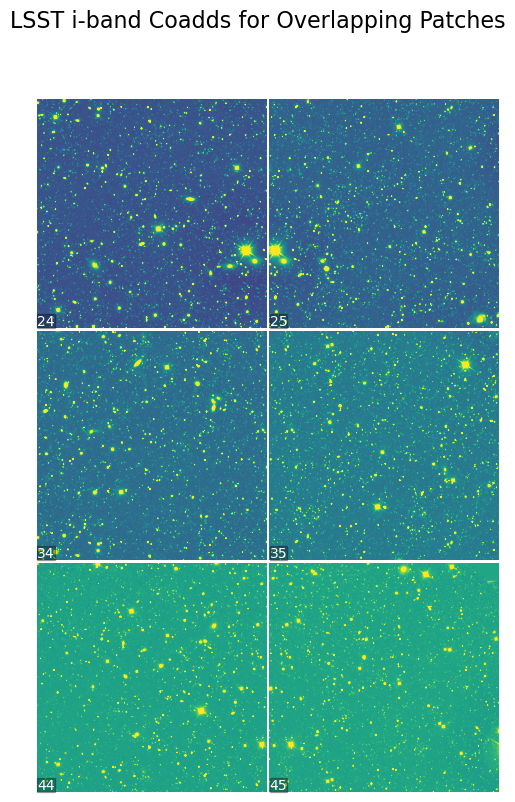

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(8, 9), sharex=True, sharey=True, gridspec_kw={'wspace': -0.4, 'hspace': 0.01})
fig.suptitle('LSST i-band Coadds for Overlapping Patches', fontsize=16)
patch_ids = [24, 25, 34, 35, 44, 45]
for idx, patch_id in enumerate(patch_ids):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    new_url = f'full_p{patch_id}.npy'
    lsst_iband_img = np.load(new_url)[3,:, :]
    ax.imshow(lsst_iband_img, norm=asinh_norm(lsst_iband_img, a=0.1), origin='lower', cmap='viridis')
    ax.text(5, 5, f'{patch_id}', color='white', fontsize=10,
        ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.3, pad=0.01))
    ax.axis('off')

# plt.tight_layout()

# Sanity Check of Unrecognized Blend Plot from [Tech Note](https://sitcomtn-128.lsst.io/#magnitude-dependence)

We need to first remove "the parent objects (if child objects exist) from the LSST DP1 catalog along with removing any sky objects and that the object is from the inner part of both a tract and a patch."

There are many columns in https://sdm-schemas.lsst.io/dp1.html#Object schema that help us accomplish this.

## Loading in Ground Catalog

In [3]:
ground_cat = pd.read_json('lsst_dets_hst.json', orient='records')
print(f"We loaded in {len(ground_cat)} objects.")
# detect_isPrimary (primary objs don't have children - either isolated or deblended children)
ground_cat = ground_cat[ground_cat['deblend_nChild'] == 0].copy()
print(f"After detect_isPrimary cut: we have {len(ground_cat)} objects")
# ground_cat = ground_cat[np.isfinite(ground_cat['mag_i'])].copy()
# there's some mags that are 83 so wet set 30 as the upper limit
# ground_cat = ground_cat[ground_cat['mag_i'] <= 40].copy()
print(f"After first magnitude cuts: we have {len(ground_cat)} objects")
ground_cat.reset_index(drop=True, inplace=True) # drop=True prevents pandas from creating a new 'index' column

We loaded in 33512 objects.
After detect_isPrimary cut: we have 30000 objects
After first magnitude cuts: we have 30000 objects


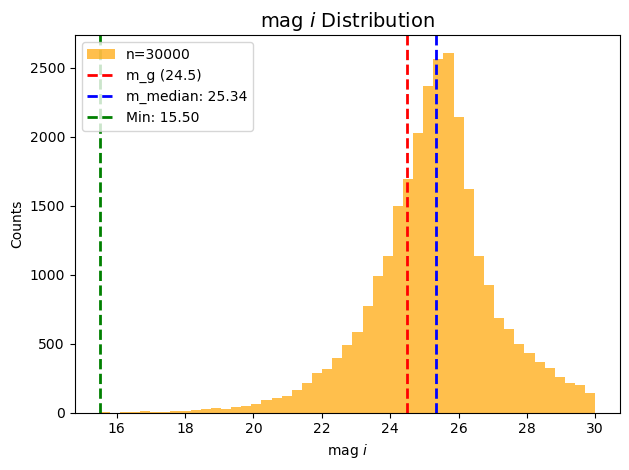

In [49]:
bins = np.linspace(ground_cat['mag_i'].min(), ground_cat[ground_cat['mag_i'] <= 30]['mag_i'].max(), 50)
# fig, axs = plt.subplots(2, 1, figsize=(8, 12))
plt.title('mag $i$ Distribution', fontsize=14)
plt.hist(ground_cat[ground_cat['mag_i'] <= 30]['mag_i'], bins=bins, color='orange', alpha=0.7, 
           label=f'n={len(ground_cat)}')
plt.axvline(24.5, color='red', linestyle='--', linewidth=2, label='m_g (24.5)')
median_mag = np.median(ground_cat[ground_cat['mag_i'] <= 30]['mag_i'])
plt.axvline(median_mag, color='blue', linestyle='--', linewidth=2, label=f'm_median: {median_mag:.2f}')
plt.axvline(ground_cat['mag_i'].min(), color='green', linestyle='--', 
              linewidth=2, label=f'Min: {ground_cat["mag_i"].min():.2f}')
plt.xlabel('mag $i$')
plt.ylabel('Counts')
plt.legend(frameon=True)
plt.tight_layout()

## Loading in Space Catalog

In [4]:
space_cat = pd.read_json('hst_dets_lsst.json', orient='records') 
print(f"We loaded in {len(space_cat)} objects.")
space_cat = space_cat[np.isfinite(space_cat['mag_F814W'])].copy()
# there's some mags that are 37 so wet set 30 as the upper limit
space_cat = space_cat[space_cat['mag_F814W'] <= 30].copy()
print(f"After first magnitude cuts: we have {len(space_cat)} objects")
space_cat.reset_index(drop=True, inplace=True) # drop=True prevents pandas from creating a new 'index' column

We loaded in 34612 objects.
After first magnitude cuts: we have 32656 objects


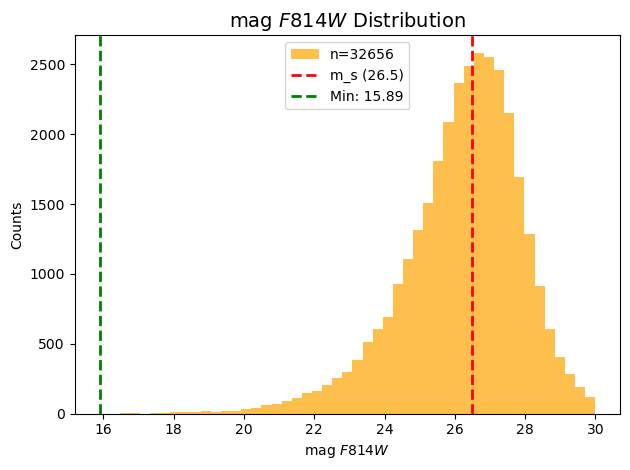

In [13]:
bins = np.linspace(space_cat['mag_F814W'].min(), space_cat['mag_F814W'].max(), 50)
# fig, axs = plt.subplots(2, 1, figsize=(8, 12))
plt.title('mag $F814W$ Distribution', fontsize=14)
plt.hist(space_cat['mag_F814W'], bins=bins, color='orange', alpha=0.7, 
           label=f'n={len(space_cat)}')
plt.axvline(26.5, color='red', linestyle='--', linewidth=2, label='m_s (26.5)')
plt.axvline(space_cat['mag_F814W'].min(), color='green', linestyle='--', 
              linewidth=2, label=f'Min: {space_cat["mag_F814W"].min():.2f}')
plt.xlabel('mag $F814W$')
plt.ylabel('Counts')
plt.legend(frameon=True)
plt.tight_layout()

In [18]:
print(f"Final catalog sizes - Ground: {len(ground_cat)}, Space: {len(space_cat)}")

Final catalog sizes - Ground: 30000, Space: 32656


## Spatial Matching w/ Search Around Sky from Astropy

In [ ]:
# --- Convert to SkyCoord ---
ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values*u.deg, dec=ground_cat['coord_dec'].values*u.deg)
space_coords = SkyCoord(ra=space_cat['RA'].values*u.deg, dec=space_cat['DEC'].values*u.deg)

# --- Pure spatial matching ---
match_radius = 2 * u.arcsec  # from tech note
unrec_blend_mask = []

for gc in ground_coords:
    idx_within = space_coords.separation(gc) < match_radius
    num_matches = np.count_nonzero(idx_within)
    unrec_blend_mask.append(num_matches >= 2)  # unrecognized blend if >=2 matches

unrec_blend_mask = np.array(unrec_blend_mask)

# --- Bin by magnitude ---
mag_bins = np.arange(18, 25, 0.5)  # matches figure x-axis
mag_centers = 0.5*(mag_bins[1:] + mag_bins[:-1])
frac_unrec, frac_err = [], []

for i in range(len(mag_bins)-1):
    in_bin = (ground_cat['mag_i'] >= mag_bins[i]) & (ground_cat['mag_i'] < mag_bins[i+1])
    Nbin = np.sum(in_bin)
    if Nbin > 0:
        Nunrec = np.sum(unrec_blend_mask[in_bin])
        frac = Nunrec / Nbin
        err = np.sqrt(frac*(1-frac)/Nbin)  # binomial error
    else:
        frac, err = np.nan, np.nan
    frac_unrec.append(frac)
    frac_err.append(err)

frac_unrec, frac_err = np.array(frac_unrec), np.array(frac_err)

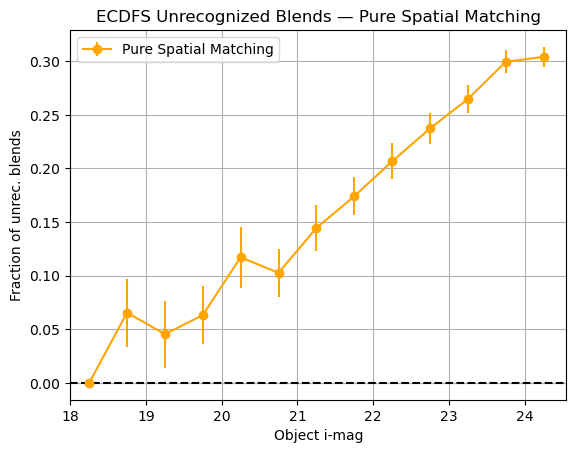

In [16]:
# --- Plot ---
plt.errorbar(mag_centers, frac_unrec, yerr=frac_err, 
             fmt='-o', color='orange', label='Pure Spatial Matching')
plt.axhline(0, ls='--', color='k')
plt.xlabel("Object i-mag")
plt.ylabel("Fraction of unrec. blends")
plt.title("ECDFS Unrecognized Blends — Pure Spatial Matching")
plt.xlim(18)
plt.legend()
plt.grid()

After magnitude limit cut (24.5): we have 8140 objects

Performing spatial matching with radius=2 arcsec...
Processing ground object 0/8140
Processing ground object 1000/8140
Processing ground object 2000/8140
Processing ground object 3000/8140
Processing ground object 4000/8140
Processing ground object 5000/8140
Processing ground object 6000/8140
Processing ground object 7000/8140
Processing ground object 8000/8140

Total unrecognized blends: 2078
Fraction of unrecognized blends: 0.255
Mag [18.5, 19.0): n_total=  61, n_unrec=  4, fraction=0.066
Mag [19.0, 19.5): n_total=  44, n_unrec=  2, fraction=0.045
Mag [19.5, 20.0): n_total=  79, n_unrec=  5, fraction=0.063
Mag [20.0, 20.5): n_total= 128, n_unrec= 15, fraction=0.117
Mag [20.5, 21.0): n_total= 185, n_unrec= 19, fraction=0.103
Mag [21.0, 21.5): n_total= 270, n_unrec= 39, fraction=0.144
Mag [21.5, 22.0): n_total= 448, n_unrec= 78, fraction=0.174
Mag [22.0, 22.5): n_total= 576, n_unrec=119, fraction=0.207
Mag [22.5, 23.0): n_total= 8

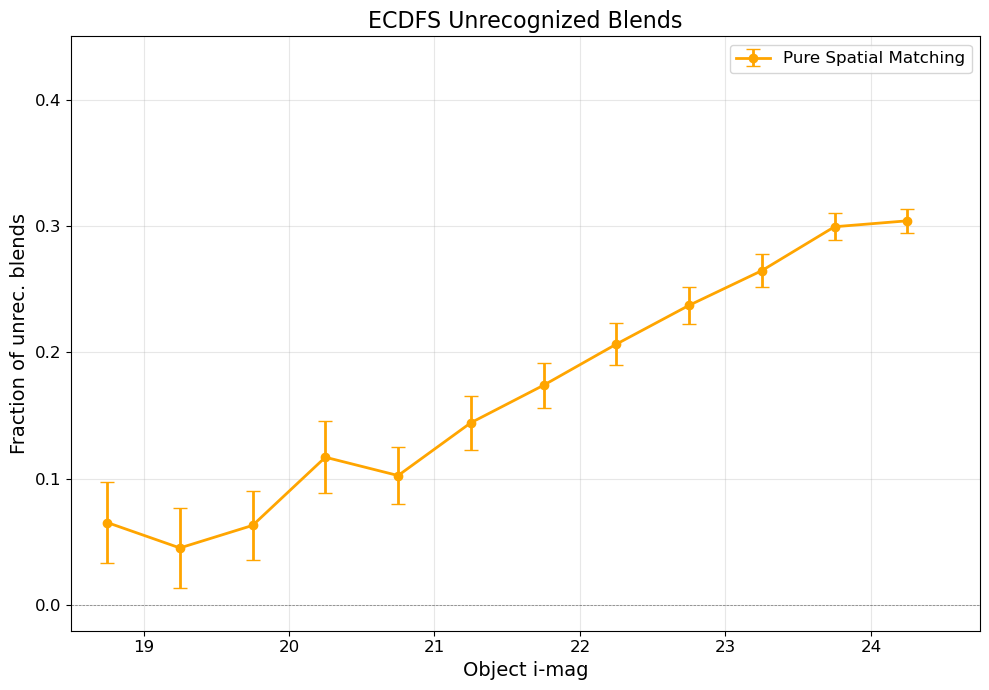


=== Summary Statistics ===
Total ground objects analyzed: 8140
Total unrecognized blends: 2078
Overall unrecognized blend fraction: 0.255

Distribution of matches per ground object:
  0 matches: 3081 objects (37.9%)
  1 matches: 2981 objects (36.6%)
  2 matches: 1539 objects (18.9%)
  3 matches: 449 objects (5.5%)
  4 matches: 71 objects (0.9%)
  5+ matches: 19 objects (0.2%)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from scipy import stats

# Apply magnitude limit from tech note (24.5 for i-band with candidate boost factor of 2)
ground_cat = ground_cat[ground_cat['mag_i'] <= 24.5].copy()
print(f"After magnitude limit cut (24.5): we have {len(ground_cat)} objects")

# Spatial matching parameters from tech note
# The tech note uses 0.7 arcsec matching radius for spatial matching
matching_radius = 2  # arcseconds

# Create SkyCoord objects for both catalogs
# Assuming columns are named 'ra' and 'dec' (adjust if different)
ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values*u.degree, 
                         dec=ground_cat['coord_dec'].values*u.degree)
space_coords = SkyCoord(ra=space_cat['RA'].values*u.degree, 
                        dec=space_cat['DEC'].values*u.degree)

print(f"\nPerforming spatial matching with radius={matching_radius} arcsec...")

# For each ground object, find ALL space objects within the matching radius
# This is key for identifying unrecognized blends
unrecognized_blend_flags = np.zeros(len(ground_cat), dtype=bool)
n_matches_per_ground = np.zeros(len(ground_cat), dtype=int)

for i, ground_coord in enumerate(ground_coords):
    if i % 1000 == 0:
        print(f"Processing ground object {i}/{len(ground_coords)}")
    
    # Find all space objects within matching radius
    separations = ground_coord.separation(space_coords)
    matches = separations < matching_radius * u.arcsec
    n_matches = np.sum(matches)
    
    n_matches_per_ground[i] = n_matches
    
    # An unrecognized blend is when a ground object matches to 2+ space objects
    if n_matches >= 2:
        unrecognized_blend_flags[i] = True

# Add flags to ground catalog
ground_cat['is_unrecognized_blend'] = unrecognized_blend_flags
ground_cat['n_space_matches'] = n_matches_per_ground

print(f"\nTotal unrecognized blends: {np.sum(unrecognized_blend_flags)}")
print(f"Fraction of unrecognized blends: {np.sum(unrecognized_blend_flags)/len(ground_cat):.3f}")

# Calculate unrecognized blend fraction as a function of magnitude
# Use magnitude bins from the plot (approximately 0.5 mag bins from 18.5 to 24.5)
mag_bins = np.arange(18.5, 25.0, 0.5)
mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2

fractions = []
errors = []
counts = []

for i in range(len(mag_bins) - 1):
    mask = (ground_cat['mag_i'] >= mag_bins[i]) & (ground_cat['mag_i'] < mag_bins[i+1])
    n_total = np.sum(mask)
    
    if n_total > 0:
        n_unrecognized = np.sum(ground_cat.loc[mask, 'is_unrecognized_blend'])
        fraction = n_unrecognized / n_total
        
        # Calculate binomial error
        error = np.sqrt(fraction * (1 - fraction) / n_total)
        
        fractions.append(fraction)
        errors.append(error)
        counts.append(n_total)
    else:
        fractions.append(np.nan)
        errors.append(np.nan)
        counts.append(0)
    
    print(f"Mag [{mag_bins[i]:.1f}, {mag_bins[i+1]:.1f}): "
          f"n_total={n_total:4d}, n_unrec={n_unrecognized if n_total > 0 else 0:3d}, "
          f"fraction={fraction if n_total > 0 else 0:.3f}")

# Convert to arrays and remove NaN values
valid_mask = ~np.isnan(fractions)
mag_centers_valid = mag_centers[valid_mask]
fractions_valid = np.array(fractions)[valid_mask]
errors_valid = np.array(errors)[valid_mask]

# Create the plot
plt.figure(figsize=(10, 7))
plt.errorbar(mag_centers_valid, fractions_valid, yerr=errors_valid, 
             fmt='o-', color='orange', linewidth=2, markersize=6,
             label='Pure Spatial Matching', capsize=5)

plt.xlabel('Object i-mag', fontsize=14)
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Set axis limits to match the original plot
plt.xlim(18.5, 24.75)
plt.ylim(-0.02, 0.45)

# Adjust tick sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add horizontal line at y=0 for reference
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"Total ground objects analyzed: {len(ground_cat)}")
print(f"Total unrecognized blends: {np.sum(unrecognized_blend_flags)}")
print(f"Overall unrecognized blend fraction: {np.sum(unrecognized_blend_flags)/len(ground_cat):.3f}")
print(f"\nDistribution of matches per ground object:")
for n in range(5):
    count = np.sum(n_matches_per_ground == n)
    print(f"  {n} matches: {count} objects ({count/len(ground_cat)*100:.1f}%)")
print(f"  5+ matches: {np.sum(n_matches_per_ground >= 5)} objects ({np.sum(n_matches_per_ground >= 5)/len(ground_cat)*100:.1f}%)")

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, search_around_sky
from astropy import units as u

def find_unrec_spatial_twostage(ground_cat, space_cat,
                                search_radius=2.0,  # arcsec
                                m_s=26.5, m_delta=2.0):
    # coords
    gcoord = SkyCoord(ground_cat['coord_ra'].values*u.deg,
                      ground_cat['coord_dec'].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)

    # Ground-ground within r (Stage A)
    gi1, gi2, gsep, _ = search_around_sky(gcoord, gcoord, search_radius*u.arcsec)
    # Count neighbors per ground object (includes self exactly once)
    N_g = np.bincount(gi1, minlength=len(ground_cat)).astype(int)

    # Ground-space within r
    gs_g, gs_s, gs_sep, _ = search_around_sky(gcoord, scoord, search_radius*u.arcsec)

    # Precompute masks
    s_mag = space_cat['mag_F814W'].values
    ms_mask_for_pair = (s_mag[gs_s] <= m_s)

    # At least one HST counterpart above m_s (denominator)
    n_ms = np.bincount(gs_g, weights=ms_mask_for_pair.astype(int), minlength=len(ground_cat)).astype(int)
    has_space_match = n_ms > 0

    # Stage A candidate set using counts before magnitude pruning on delta
    # (but still respecting the HST completeness limit m_s)
    N_s_hat = n_ms
    candidates = N_s_hat > N_g

    # Stage C: apply m_delta only to candidates; recompute N_s for them
    is_unrecognized = np.zeros(len(ground_cat), dtype=bool)
    is_recognized = np.zeros(len(ground_cat), dtype=bool)

    # recognized = N_s_hat == N_g > 1 (before m_delta)
    is_recognized[(N_g > 1) & (N_s_hat == N_g)] = True

    # For each candidate, apply m_delta to the space matches for that ground object
    # and decide final unrecognized based on surviving N_s
    if np.any(candidates):
        # group pairs by ground index
        pairs_by_g = {}
        for k, sidx, pass_ms in zip(gs_g, gs_s, ms_mask_for_pair):
            if not pass_ms:
                continue
            pairs_by_g.setdefault(k, []).append(sidx)

        cand_idx = np.where(candidates)[0]
        for g in cand_idx:
            s_indices = pairs_by_g.get(g, [])
            if len(s_indices) == 0:
                continue
            mags = s_mag[s_indices]
            m_bright = np.min(mags)
            keep = mags <= (m_bright + m_delta)
            N_s = int(np.sum(keep))
            if N_s > N_g[g]:
                is_unrecognized[g] = True

    return is_unrecognized, is_recognized, has_space_match, N_g, N_s_hat



def find_unrecognized_blends_spatial(ground_cat, space_cat, 
                                     search_radius=2.0,  # 5" as per tech note
                                     m_s=26.5,  # space magnitude limit
                                     m_delta=2):  # magnitude difference limit
    """
    Identify unrecognized blends using search_around_sky for efficient matching.
    """
    
    # Create SkyCoord objects
    ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values*u.degree, 
                            dec=ground_cat['coord_dec'].values*u.degree)
    space_coords = SkyCoord(ra=space_cat['RA'].values*u.degree,
                           dec=space_cat['DEC'].values*u.degree)
    
    # Use search_around_sky to find all ground-ground pairs within radius
    # This efficiently handles Step 1: finding N_g for each ground object
    ground_idx1, ground_idx2, ground_sep, _ = search_around_sky(
        ground_coords, ground_coords, search_radius*u.arcsec
    )
    
    # Use search_around_sky to find all ground-space pairs within radius
    # This efficiently handles Step 2: finding N_s for each ground object
    ground_idx_space, space_idx, ground_space_sep, _ = search_around_sky(
        ground_coords, space_coords, search_radius*u.arcsec
    )
    
    # Count N_g for each ground object (including self-matches)
    n_ground_matches = np.zeros(len(ground_cat), dtype=int)
    for idx in range(len(ground_cat)):
        n_ground_matches[idx] = np.sum(ground_idx1 == idx)
    
    # Process space matches and apply magnitude cuts
    is_unrecognized_blend = np.zeros(len(ground_cat), dtype=bool)
    is_recognized_blend = np.zeros(len(ground_cat), dtype=bool)
    has_space_match = np.zeros(len(ground_cat), dtype=bool)
    n_space_matches = np.zeros(len(ground_cat), dtype=int)
    
    # Group space matches by ground object
    for g_idx in range(len(ground_cat)):
        # Find all space matches for this ground object
        space_match_mask = ground_idx_space == g_idx
        if not np.any(space_match_mask):
            continue
            
        matched_space_indices = space_idx[space_match_mask]
        matched_space = space_cat.iloc[matched_space_indices]
        
        # Apply magnitude cut: m_F814W < m_s
        mag_mask = matched_space['mag_F814W'] < m_s
        
        if np.sum(mag_mask) == 0:
            continue
        
        # Apply magnitude difference cut if multiple matches
        valid_mags = matched_space.loc[mag_mask, 'mag_F814W'].values
        if len(valid_mags) > 1:
            m_bright = np.min(valid_mags)
            m_faint = np.max(valid_mags)
            
            # Check if magnitude spread is within limit
            if (m_faint - m_bright) > m_delta:
                # Keep only objects within m_delta of the brightest
                mag_mask = mag_mask & (matched_space['mag_F814W'] < (m_bright + m_delta))
        
        # Count final number of valid space matches
        N_s = np.sum(mag_mask)
        
        if N_s == 0:
            continue
        
        # This object has valid space matches
        has_space_match[g_idx] = True
        n_space_matches[g_idx] = N_s
        N_g = n_ground_matches[g_idx]
        
        # Apply classification logic
        if N_s > N_g:
            is_unrecognized_blend[g_idx] = True
        elif N_s == N_g and N_g > 1:
            is_recognized_blend[g_idx] = True
    
    return is_unrecognized_blend, is_recognized_blend, has_space_match, n_ground_matches, n_space_matches

def calculate_blend_fraction_by_magnitude(ground_cat, is_blend, has_match, mag_points, bin_width=0.5):
    """
    Calculate fraction of unrecognized blends at specific magnitude points.
    Uses bins centered on the plotting points.
    """
    fractions = []
    errors = []
    plot_points = []
    counts = []
    
    for mag_point in mag_points:
        # Define bin around this point
        mag_min = mag_point - bin_width/2
        mag_max = mag_point + bin_width/2
        
        # Select objects in this magnitude bin that have space matches
        mask_mag = (ground_cat['mag_i'] >= mag_min) & (ground_cat['mag_i'] < mag_max)
        mask_matched = mask_mag & has_match
        
        n_matched = np.sum(mask_matched)  # Objects with at least one space match
        if n_matched == 0:
            continue
            
        n_blends = np.sum(mask_matched & is_blend)
        
        # Calculate fraction: unrecognized blends / objects with space matches
        fraction = n_blends / n_matched
        
        # Binomial error
        error = np.sqrt(fraction * (1 - fraction) / n_matched) if n_matched > 0 else 0
        
        fractions.append(fraction)
        errors.append(error)
        plot_points.append(mag_point)  # Plot at the exact magnitude point
        counts.append((n_blends, n_matched))
        
        print(f"Mag {mag_point:.1f} [{mag_min:.2f}, {mag_max:.2f}]: "
              f"{n_blends:3d}/{n_matched:4d} = {fraction:.3f} ± {error:.3f}")
    
    return np.array(plot_points), np.array(fractions), np.array(errors), counts

# ground_cat_filtered = ground_cat[ground_cat['mag_i'] <= 24.5].copy()
ground_cat_filtered = ground_cat.copy()
print(f"Ground catalog (all magnitudes): {len(ground_cat_filtered)} objects")
# print(f"Ground catalog after m_i <= 24.5: {len(ground_cat_filtered)} objects")

# Space catalog: keep all with finite magnitudes
space_cat_filtered = space_cat.copy()
print(f"Space catalog: {len(space_cat_filtered)} objects")

# Find unrecognized blends using spatial matching with search_around_sky
print("\nIdentifying unrecognized blends using search_around_sky...")
is_unrecognized_blend, is_recognized_blend, has_space_match, n_ground, n_space = find_unrec_spatial_twostage(
    ground_cat_filtered, 
    space_cat_filtered,
    search_radius=2.0,  # 5 arcsec as per tech note
    m_s=26.5,
    m_delta=2.0
)

# is_unrecognized_blend, is_recognized_blend, has_space_match, n_ground, n_space = find_unrecognized_blends_spatial(
#     ground_cat_filtered, 
#     space_cat_filtered,
#     search_radius=2.0,  # 5 arcsec as per tech note
#     m_s=26.5,
#     m_delta=2.0
# )

n_with_matches = np.sum(has_space_match)
print(f"Objects with at least one space match: {n_with_matches}/{len(ground_cat_filtered)}")
print(f"Found {np.sum(is_unrecognized_blend)} unrecognized blends")
print(f"Found {np.sum(is_recognized_blend)} recognized blends")


# # Apply magnitude cut AFTER matching, only for analysis
# mag_analysis_mask = ground_cat_filtered['mag_i'] <= 24.5
# print(f"\nAnalyzing objects with m_i <= 24.5: {np.sum(mag_analysis_mask)} objects")

# n_with_matches = np.sum(has_space_match & mag_analysis_mask)
# print(f"Objects with at least one space match (m_i <= 24.5): {n_with_matches}")
# print(f"Found {np.sum(is_unrecognized_blend & mag_analysis_mask)} unrecognized blends (m_i <= 24.5)")
# print(f"Found {np.sum(is_recognized_blend & mag_analysis_mask)} recognized blends (m_i <= 24.5)")

Ground catalog (all magnitudes): 30000 objects
Space catalog: 32656 objects

Identifying unrecognized blends using search_around_sky...
Objects with at least one space match: 14026/30000
Found 1445 unrecognized blends
Found 1127 recognized blends


In [54]:
def find_unrec_spatial_twostage_full(
    ground_cat, space_cat,
    search_radius=2.0,   # arcsec
    m_s=26.5,            # space completeness limit
    m_delta=2.0,         # magnitude window around brightest space match
    ms_strict=True       # True -> mag_F814W < m_s; False -> <=
):
    """
    Implements the tech note's 'Stage A' candidate counting and 'Stage C' magnitude refinement
    for spatial matching only. Returns per-object counts before and after m_delta, as well as
    masks for unrecognized, recognized, pure, spurious, and eligibility.

    Returns:
        is_unrecognized: final classification after m_delta (bool)
        is_recognized: recognized blends based on Stage A (N_s_hat == N_g > 1) (bool)
        is_pure: pure objects based on Stage A (N_s_hat == N_g == 1) (bool)
        is_spurious: Stage A spurious/missing-space (N_g > N_s_hat) (bool)
        eligible_mask: objects used for fractions per the note (N_s_hat >= N_g) (bool)
        has_space_match_ms: N_s_hat > 0 (bool)
        N_g: ground counts within radius including self (int array)
        N_s_hat: space counts after m_s cut (Stage A) (int array)
        N_s_final: space counts after m_delta applied to Stage A space matches (int array)
    """
    # Sky coords
    gcoord = SkyCoord(ground_cat['coord_ra'].values*u.deg,
                      ground_cat['coord_dec'].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)
    
    # Ground-ground within r (Stage A: define N_g)
    gi1, gi2, _, _ = search_around_sky(gcoord, gcoord, search_radius*u.arcsec)
    # Count neighbors per ground object (includes self exactly once)
    N_g = np.bincount(gi1, minlength=len(ground_cat)).astype(int)

    # Ground-space within r (Stage A: define N_s_hat)
    gs_g, gs_s, _, _ = search_around_sky(gcoord, scoord, search_radius*u.arcsec)
    s_mag = space_cat['mag_F814W'].values

    if ms_strict:
        pass_ms = s_mag[gs_s] < m_s
    else:
        pass_ms = s_mag[gs_s] <= m_s

    N_s_hat = np.bincount(gs_g, weights=pass_ms.astype(int), minlength=len(ground_cat)).astype(int)
    has_space_match_ms = N_s_hat > 0

    # Stage A classification (before m_delta)
    # - spurious/missing space: N_g > N_s_hat  (ignored for subsequent analysis)
    # - pure:                    N_g = N_s_hat = 1
    # - recognized:              N_g = N_s_hat > 1
    # - candidate unrecognized:  N_s_hat > N_g  (go to Stage C)
    is_spurious = N_g > N_s_hat
    is_pure = (N_g == 1) & (N_s_hat == 1)
    is_recognized = (N_g > 1) & (N_s_hat == N_g)
    candidates = N_s_hat > N_g

    # Stage C: apply m_delta only to the candidate set
    # Build per-ground list of space matches that pass m_s
    pairs_by_g = {}
    for g_idx, s_idx, ok in zip(gs_g, gs_s, pass_ms):
        if not ok:
            continue
        if g_idx not in pairs_by_g:
            pairs_by_g[g_idx] = []
        pairs_by_g[g_idx].append(s_idx)

    # Final counts after m_delta for every ground object
    N_s_final = np.zeros(len(ground_cat), dtype=int)
    is_unrecognized = np.zeros(len(ground_cat), dtype=bool)

    # For all objects that have any space match after m_s, compute N_s_final
    # - For non-candidates, N_s_final is still computed (useful for diagnostics),
    #   but only candidates can flip to unrecognized after m_delta.
    for g in np.where(has_space_match_ms)[0]:
        s_indices = pairs_by_g.get(g, [])
        if len(s_indices) == 0:
            N_s_final[g] = 0
            continue
        mags = s_mag[s_indices]
        m_bright = np.min(mags)
        keep = mags <= (m_bright + m_delta)  # strictness here is not critical; using <= matches the text’s intent
        N_s = int(np.sum(keep))
        N_s_final[g] = N_s
        if candidates[g] and (N_s > N_g[g]):
            is_unrecognized[g] = True

    # Eligible for fractions per the note = not spurious at Stage A
    eligible_mask = ~is_spurious

    return (is_unrecognized, is_recognized, is_pure, is_spurious,
            eligible_mask, has_space_match_ms, N_g, N_s_hat, N_s_final)

print("\nIdentifying unrecognized blends using two-stage spatial matching (full bookkeeping)...")
(
    is_unrecognized_blend,
    is_recognized_blend,
    is_pure,
    is_spurious,
    eligible_mask,
    has_space_match_ms,
    n_ground,       # N_g
    n_space_hat,    # N_s_hat (after m_s)
    n_space_final   # N_s_final (after m_delta)
) = find_unrec_spatial_twostage_full(
    ground_cat,
    space_cat,
    search_radius=2.0,
    m_s=26.5,
    m_delta=2.0,
    ms_strict=True
)

print(f"Objects with at least one space match after m_s: {np.sum(has_space_match_ms)}/{len(ground_cat)}")
print(f"Eligible for analysis (N_s_hat >= N_g): {np.sum(eligible_mask)}")
print(f"Found unrecognized blends (final): {np.sum(is_unrecognized_blend)}")
print(f"Found recognized blends (Stage A): {np.sum(is_recognized_blend)}")
print(f"Found pure (Stage A): {np.sum(is_pure)}")
print(f"Spurious / missing space (ignored): {np.sum(is_spurious)}")


Identifying unrecognized blends using two-stage spatial matching (full bookkeeping)...
Objects with at least one space match after m_s: 14026/30000
Eligible for analysis (N_s_hat >= N_g): 11884
Found unrecognized blends (final): 1445
Found recognized blends (Stage A): 1127
Found pure (Stage A): 8888
Spurious / missing space (ignored): 18116


Mag 18.0 [17.75, 18.25]:   0/  13 = 0.000 ± 0.000
Mag 18.5 [18.25, 18.75]:   0/  24 = 0.000 ± 0.000
Mag 19.0 [18.75, 19.25]:   0/  25 = 0.000 ± 0.000
Mag 19.5 [19.25, 19.75]:   1/  36 = 0.028 ± 0.027
Mag 20.0 [19.75, 20.25]:   2/  54 = 0.037 ± 0.026
Mag 20.5 [20.25, 20.75]:   2/  95 = 0.021 ± 0.015
Mag 21.0 [20.75, 21.25]:   4/ 122 = 0.033 ± 0.016
Mag 21.5 [21.25, 21.75]:  16/ 194 = 0.082 ± 0.020
Mag 22.0 [21.75, 22.25]:  20/ 307 = 0.065 ± 0.014
Mag 22.5 [22.25, 22.75]:  41/ 392 = 0.105 ± 0.015
Mag 23.0 [22.75, 23.25]:  78/ 582 = 0.134 ± 0.014
Mag 23.5 [23.25, 23.75]: 160/ 904 = 0.177 ± 0.013
Mag 24.0 [23.75, 24.25]: 252/1205 = 0.209 ± 0.012
Mag 24.5 [24.25, 24.75]: 332/1665 = 0.199 ± 0.010

=== Summary ===
Total eligible (N_s_hat >= N_g): 11884
Total unrecognized blends (final): 1445
Overall blend fraction (among eligible): 0.122

We find that for 23 < i <= 24.5, 19.2% of objects are unrecognized blends (eligible denominator).

=== Diagnostic Info (using final N_s) ===
Pure/isolated (

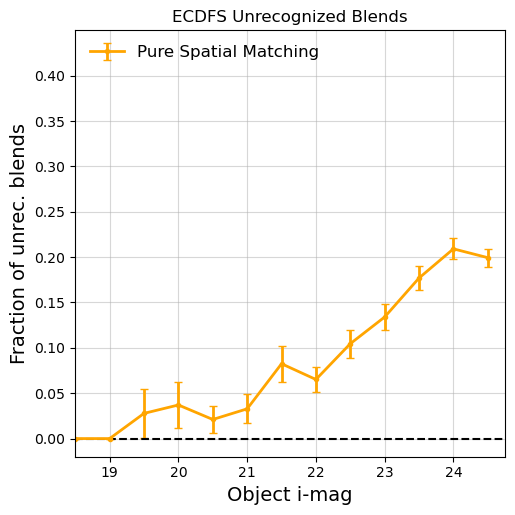

In [57]:
def blend_fraction_by_mag(
    ground_cat,
    is_unrec,            # final unrec mask after m_delta
    eligible_mask,       # per note: ~spurious (N_s_hat >= N_g)
    mag_points,
    bin_width=0.5
):
    fracs, errs, pts, counts = [], [], [], []
    mag = ground_cat['mag_i'].values

    for c in mag_points:
        lo, hi = c - bin_width/2, c + bin_width/2
        in_bin = (mag >= lo) & (mag < hi)

        denom_mask = in_bin & eligible_mask
        n_denom = int(np.sum(denom_mask))
        if n_denom == 0:
            continue

        numer = int(np.sum(in_bin & is_unrec))
        frac = numer / n_denom
        err = np.sqrt(frac*(1-frac)/n_denom) if n_denom > 0 else 0.0

        fracs.append(frac)
        errs.append(err)
        pts.append(c)
        counts.append((numer, n_denom))
        print(f"Mag {c:.1f} [{lo:.2f}, {hi:.2f}]: {numer:3d}/{n_denom:4d} = {frac:.3f} ± {err:.3f}")

    return np.array(pts), np.array(fracs), np.array(errs), counts

# Fractions per the tech note (denominator excludes spurious)
mag_points = np.arange(18, 24.75, 0.5)
plot_points, fractions, errors, counts = blend_fraction_by_mag(
    ground_cat,
    is_unrecognized_blend,
    eligible_mask,       # <-- note: using eligible_mask, not has_space_match
    mag_points,
    bin_width=0.5
)

plt.figure(figsize=(5.25, 5.25))
plt.errorbar(plot_points, fractions, yerr=errors,
             fmt='o-', color='orange', linewidth=2, markersize=3,
             label='Pure Spatial Matching', capsize=3, capthick=1)
plt.xlabel('Object i-mag', fontsize=14)
plt.axhline(0, ls='--', color='k')
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=12, loc='upper left', frameon=False)
plt.xlim(18.5, 24.75)
plt.ylim(-0.02, 0.45)
plt.xticks(np.arange(19, 25, 1))
plt.yticks(np.arange(0, 0.45, 0.05))
plt.tight_layout()

# Summary with consistent counts
print("\n=== Summary ===")
print(f"Total eligible (N_s_hat >= N_g): {np.sum(eligible_mask)}")
print(f"Total unrecognized blends (final): {np.sum(is_unrecognized_blend)}")
print(f"Overall blend fraction (among eligible): {np.sum(is_unrecognized_blend)/np.sum(eligible_mask):.3f}")

mag_range_mask = (ground_cat['mag_i'] > 23) & (ground_cat['mag_i'] <= 24.5)
eligible_in_range = mag_range_mask & eligible_mask
blends_in_range = mag_range_mask & is_unrecognized_blend
fraction_23_245 = np.sum(blends_in_range) / np.sum(eligible_in_range) * 100
print(f"\nWe find that for 23 < i <= 24.5, {fraction_23_245:.1f}% of objects are unrecognized blends (eligible denominator).")

# Diagnostics that use N_s_final, not N_s_hat, for clarity
print("\n=== Diagnostic Info (using final N_s) ===")
pure_mask_final = (n_ground == 1) & (n_space_final == 1) & eligible_mask
print(f"Pure/isolated (N_g=N_s_final=1, eligible): {np.sum(pure_mask_final)}")
print(f"Unrecognized (N_s_final > N_g, eligible): {np.sum((n_space_final > n_ground) & eligible_mask)}")
print(f"Recognized (N_s_hat = N_g > 1): {np.sum(is_recognized_blend)}  [Stage A definition]")
print(f"Stage A spurious (ignored): {np.sum(is_spurious)}")
print(f"Ineligible but had any space match after m_s: {np.sum((~eligible_mask) & has_space_match_ms)}")

Mag 18.0 [17.75, 18.25]:   0/  13 = 0.000 ± 0.000
Mag 18.5 [18.25, 18.75]:   0/  24 = 0.000 ± 0.000
Mag 19.0 [18.75, 19.25]:   0/  25 = 0.000 ± 0.000
Mag 19.5 [19.25, 19.75]:   1/  36 = 0.028 ± 0.027
Mag 20.0 [19.75, 20.25]:   2/  53 = 0.038 ± 0.026
Mag 20.5 [20.25, 20.75]:   2/  94 = 0.021 ± 0.015
Mag 21.0 [20.75, 21.25]:   4/ 122 = 0.033 ± 0.016
Mag 21.5 [21.25, 21.75]:  14/ 196 = 0.071 ± 0.018
Mag 22.0 [21.75, 22.25]:  14/ 306 = 0.046 ± 0.012
Mag 22.5 [22.25, 22.75]:  39/ 389 = 0.100 ± 0.015
Mag 23.0 [22.75, 23.25]:  71/ 582 = 0.122 ± 0.014
Mag 23.5 [23.25, 23.75]: 149/ 914 = 0.163 ± 0.012
Mag 24.0 [23.75, 24.25]: 237/1243 = 0.191 ± 0.011
Mag 24.5 [24.25, 24.75]: 290/1703 = 0.170 ± 0.009
[r=1.8"] Eligible in 23–24.5: 574/3286 = 0.175
Mag 18.0 [17.75, 18.25]:   0/  13 = 0.000 ± 0.000
Mag 18.5 [18.25, 18.75]:   0/  24 = 0.000 ± 0.000
Mag 19.0 [18.75, 19.25]:   0/  25 = 0.000 ± 0.000
Mag 19.5 [19.25, 19.75]:   1/  36 = 0.028 ± 0.027
Mag 20.0 [19.75, 20.25]:   2/  54 = 0.037 ± 0.026
Mag

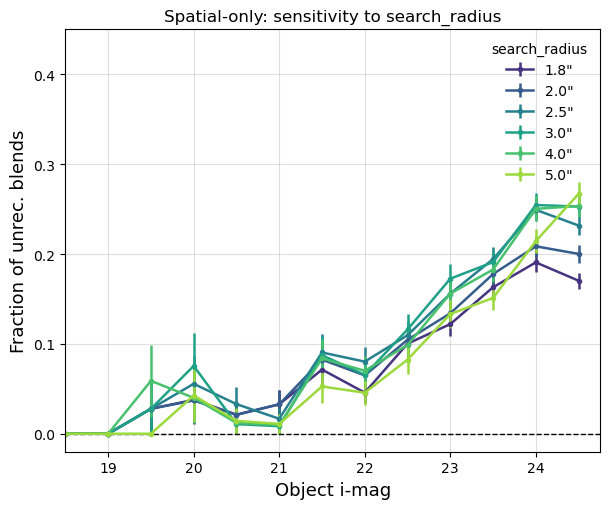

In [33]:
from matplotlib import cm

def run_spatial_once(ground_cat, space_cat, search_radius=2.0, m_s=26.5, m_delta=2.0, ms_strict=True):
    res = find_unrec_spatial_twostage_full(
        ground_cat, space_cat,
        search_radius=search_radius, m_s=m_s, m_delta=m_delta, ms_strict=ms_strict
    )
    (is_unrec, is_rec, is_pure, is_spurious, eligible_mask, has_space_match_ms,
     N_g, N_s_hat, N_s_final) = res
    return {
        'is_unrec': is_unrec,
        'is_rec': is_rec,
        'is_pure': is_pure,
        'is_spurious': is_spurious,
        'eligible': eligible_mask,
        'has_space': has_space_match_ms,
        'N_g': N_g,
        'N_s_hat': N_s_hat,
        'N_s_final': N_s_final
    }

def sweep_search_radius(ground_cat, space_cat, radii, mag_points, bin_width=0.5, m_s=26.5, m_delta=2.0, ms_strict=True):
    curves = {}
    summaries = []
    for r in radii:
        out = run_spatial_once(ground_cat, space_cat, search_radius=r, m_s=m_s, m_delta=m_delta, ms_strict=ms_strict)
        pts, fracs, errs, counts = blend_fraction_by_mag(ground_cat, out['is_unrec'], out['eligible'], mag_points, bin_width)
        curves[r] = {'pts': pts, 'fracs': fracs, 'errs': errs, 'counts': counts, **out}
        # overall fraction in 23–24.5 for quick comparison
        rng = (ground_cat['mag_i'] > 23) & (ground_cat['mag_i'] <= 24.5)
        denom = np.sum(rng & out['eligible'])
        numer = np.sum(rng & out['is_unrec'])
        frac = numer/denom if denom > 0 else np.nan
        summaries.append((r, denom, numer, frac))
        print(f"[r={r:.1f}\"] Eligible in 23–24.5: {numer}/{denom} = {frac:.3f}")
    return curves, summaries

# Run the sweep
mag_points = np.arange(18, 24.75, 0.5)
radii = [1.75, 2.0, 2.5, 3.0, 4.0, 5.0]
curves, summaries = sweep_search_radius(
    ground_cat_filtered, space_cat_filtered,
    radii=radii, mag_points=mag_points, bin_width=0.5, m_s=26.5, m_delta=2.0, ms_strict=True
)

# Overlay plot
plt.figure(figsize=(6.2, 5.2))
colors = cm.viridis(np.linspace(0.15, 0.85, len(radii)))
for c, r in zip(colors, radii):
    plt.errorbar(curves[r]['pts'], curves[r]['fracs'], yerr=curves[r]['errs'],
                 fmt='o-', ms=3, lw=1.8, color=c, label=f'{r:.1f}"')
plt.axhline(0, ls='--', color='k', lw=1)
plt.xlabel('Object i-mag', fontsize=13)
plt.ylabel('Fraction of unrec. blends', fontsize=13)
plt.title('Spatial-only: sensitivity to search_radius', fontsize=12)
plt.legend(title='search_radius', frameon=False, fontsize=10)
plt.grid(alpha=0.4)
plt.xlim(18.5, 24.75)
plt.ylim(-0.02, 0.45)
plt.tight_layout()

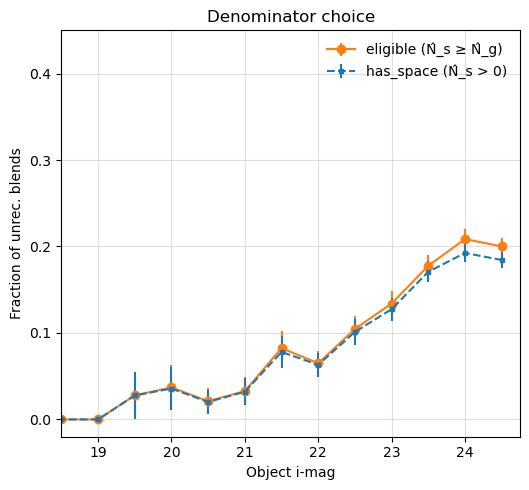

In [34]:
def fraction_with_denominator(ground_cat, is_unrec, denom_mask, mag_points, bin_width=0.5):
    fracs, errs, pts = [], [], []
    mag = ground_cat['mag_i'].values
    for c in mag_points:
        lo, hi = c - bin_width/2, c + bin_width/2
        in_bin = (mag >= lo) & (mag < hi)
        denom = np.sum(in_bin & denom_mask)
        if denom == 0:
            continue
        numer = np.sum(in_bin & is_unrec)
        f = numer/denom
        e = np.sqrt(f*(1-f)/denom) if denom > 0 else 0
        fracs.append(f); errs.append(e); pts.append(c)
    return np.array(pts), np.array(fracs), np.array(errs)

# For your current r=2.0 case:
r = 2.0
out = curves[r]
pts1, fr1, er1 = fraction_with_denominator(ground_cat_filtered, out['is_unrec'], out['eligible'], mag_points)
pts2, fr2, er2 = fraction_with_denominator(ground_cat_filtered, out['is_unrec'], out['has_space'], mag_points)

plt.figure(figsize=(5.4, 5.0))
plt.errorbar(pts1, fr1, yerr=er1, fmt='o-', label='eligible (N̂_s ≥ N̂_g)', color='tab:orange')
plt.errorbar(pts2, fr2, yerr=er2, fmt='s--', label='has_space (N̂_s > 0)', color='tab:blue', ms=3)
plt.xlabel('Object i-mag'); plt.ylabel('Fraction of unrec. blends')
plt.title('Denominator choice')
plt.grid(alpha=0.4); plt.legend(frameon=False); plt.xlim(18.5, 24.75); plt.ylim(-0.02, 0.45); plt.tight_layout()

In [35]:
def per_bin_budget(ground_cat, out, mag_points, bin_width=0.5):
    rows = []
    mi = ground_cat['mag_i'].values
    for c in mag_points:
        lo, hi = c - bin_width/2, c + bin_width/2
        inb = (mi >= lo) & (mi < hi)
        rows.append({
            'center': c,
            'n_in_bin': int(np.sum(inb)),
            'n_spurious': int(np.sum(inb & out['is_spurious'])),
            'n_eligible': int(np.sum(inb & out['eligible'])),
            'n_pure': int(np.sum(inb & out['is_pure'])),
            'n_recognized': int(np.sum(inb & out['is_rec'])),
            'n_unrecognized': int(np.sum(inb & out['is_unrec']))
        })
    return pd.DataFrame(rows)

budget = per_bin_budget(ground_cat_filtered, curves[2.0], mag_points)
print(budget.loc[(budget['center']>=23.5) & (budget['center']<=24.5)])

    center  n_in_bin  n_spurious  n_eligible  n_pure  n_recognized  \
11    23.5      1487         581         906     620            39   
12    24.0      2093         880        1213     815            91   
13    24.5      2836        1162        1674    1162           163   

    n_unrecognized  
11             161  
12             253  
13             335  


In [36]:
def delta_effect_summary(ground_cat, out, mag_points, bin_width=0.5):
    rows = []
    mi = ground_cat['mag_i'].values
    for c in mag_points:
        lo, hi = c - bin_width/2, c + bin_width/2
        inb = (mi >= lo) & (mi < hi)
        rows.append({
            'center': c,
            'median_Ng': np.median(out['N_g'][inb]) if np.any(inb) else np.nan,
            'median_Ns_hat': np.median(out['N_s_hat'][inb]) if np.any(inb) else np.nan,
            'median_Ns_final': np.median(out['N_s_final'][inb]) if np.any(inb) else np.nan,
            'frac_reduced_by_delta': (np.sum(inb & (out['N_s_final'] < out['N_s_hat'])) /
                                      np.sum(inb & (out['N_s_hat'] > 0))
                                      if np.any(inb & (out['N_s_hat'] > 0)) else np.nan)
        })
    return pd.DataFrame(rows)
for 
delta_tab = delta_effect_summary(ground_cat_filtered, curves[2.0], mag_points)
print(delta_tab.loc[(delta_tab['center']>=23.5) & (delta_tab['center']<=24.5)])

    center  median_Ng  median_Ns_hat  median_Ns_final  frac_reduced_by_delta
11    23.5        1.0            1.0              1.0               0.112407
12    24.0        1.0            1.0              1.0               0.049467
13    24.5        1.0            1.0              1.0               0.011558


In [37]:
def sweep_ms_mdelta(ground_cat, space_cat, search_radius=2.0,
                    m_s_vals=(26.3, 26.5, 26.7), m_delta_vals=(1.5, 2.0, 2.5)):
    results = []
    for ms in m_s_vals:
        for md in m_delta_vals:
            out = run_spatial_once(ground_cat, space_cat, search_radius=search_radius, m_s=ms, m_delta=md, ms_strict=True)
            rng = (ground_cat['mag_i'] > 23) & (ground_cat['mag_i'] <= 24.5)
            denom = np.sum(rng & out['eligible'])
            numer = np.sum(rng & out['is_unrec'])
            frac = numer/denom if denom > 0 else np.nan
            results.append((ms, md, denom, numer, frac))
            print(f"m_s={ms:.1f}, m_delta={md:.1f}: {numer}/{denom} = {frac:.3f}")
    return results

grid_results = sweep_ms_mdelta(ground_cat_filtered, space_cat_filtered, search_radius=2.0)

m_s=26.3, m_delta=1.5: 431/3217 = 0.134
m_s=26.3, m_delta=2.0: 579/3217 = 0.180
m_s=26.3, m_delta=2.5: 682/3217 = 0.212
m_s=26.5, m_delta=1.5: 450/3232 = 0.139
m_s=26.5, m_delta=2.0: 621/3232 = 0.192
m_s=26.5, m_delta=2.5: 753/3232 = 0.233
m_s=26.7, m_delta=1.5: 456/3250 = 0.140
m_s=26.7, m_delta=2.0: 644/3250 = 0.198
m_s=26.7, m_delta=2.5: 809/3250 = 0.249


Mag 18.0 [17.75, 18.25]:   0/  13 = 0.000 ± 0.000
Mag 18.5 [18.25, 18.75]:   0/  24 = 0.000 ± 0.000
Mag 19.0 [18.75, 19.25]:   0/  25 = 0.000 ± 0.000
Mag 19.5 [19.25, 19.75]:   1/  36 = 0.028 ± 0.027
Mag 20.0 [19.75, 20.25]:   2/  56 = 0.036 ± 0.025
Mag 20.5 [20.25, 20.75]:   2/  99 = 0.020 ± 0.014
Mag 21.0 [20.75, 21.25]:   4/ 125 = 0.032 ± 0.016
Mag 21.5 [21.25, 21.75]:  16/ 205 = 0.078 ± 0.019
Mag 22.0 [21.75, 22.25]:  20/ 317 = 0.063 ± 0.014
Mag 22.5 [22.25, 22.75]:  41/ 405 = 0.101 ± 0.015
Mag 23.0 [22.75, 23.25]:  78/ 612 = 0.127 ± 0.013
Mag 23.5 [23.25, 23.75]: 160/ 943 = 0.170 ± 0.012
Mag 24.0 [23.75, 24.25]: 252/1314 = 0.192 ± 0.011
Mag 24.5 [24.25, 24.75]: 332/1817 = 0.183 ± 0.009

=== Summary ===
Total objects with space matches: 14026
Total unrecognized blends: 1445
Overall blend fraction (among matched): 0.103

We find that for objects with 23 < i < 24.5, 17.9% of objects are unrecognized blends.

=== Diagnostic Info ===
Pure/isolated objects (N_g=N_s=1): 8888
Objects with

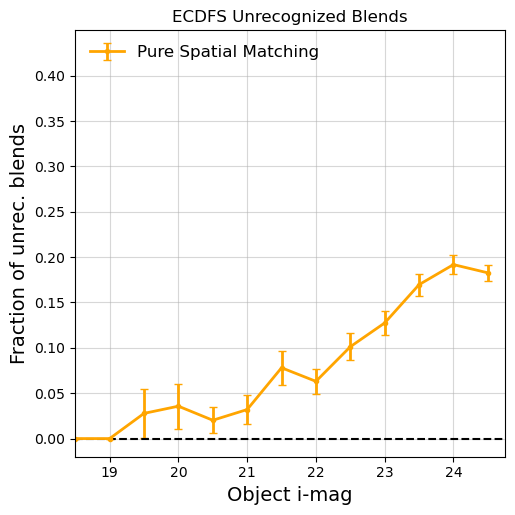

In [59]:
# Calculate fractions in magnitude bins
mag_points = np.arange(18, 24.75, 0.5)
plot_points, fractions, errors, counts = calculate_blend_fraction_by_magnitude(
    ground_cat, 
    is_unrecognized_blend, 
    has_space_match, 
    mag_points, 
    bin_width=0.5
)

# plot_mask = ground_cat_filtered['mag_i'] <= 24.5
# plot_points, fractions, errors, counts = calculate_blend_fraction_by_magnitude(
#     ground_cat_filtered[plot_mask], 
#     is_unrecognized_blend[plot_mask], 
#     has_space_match[plot_mask], 
#     mag_points, 
#     bin_width=0.5
# )
# plot_points, fractions, errors, counts = calculate_blend_fraction_by_magnitude(
#     ground_cat_filtered[mag_analysis_mask], 
#     is_unrecognized_blend[mag_analysis_mask], 
#     has_space_match[mag_analysis_mask], 
#     mag_points, 
#     bin_width=0.5
# )

# Create the plot
plt.figure(figsize=(5.25, 5.25))
plt.errorbar(plot_points, fractions, yerr=errors, 
             fmt='o-', color='orange', linewidth=2, markersize=3,
             label='Pure Spatial Matching', capsize=3, capthick=1)

plt.xlabel('Object i-mag', fontsize=14)
plt.axhline(0, ls='--', color='k')
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=12, loc='upper left', frameon=False)

# Set axis limits to match reference
plt.xlim(18.5, 24.75)
plt.ylim(-0.02, 0.45)

# Add ticks
plt.xticks(np.arange(19, 25, 1))
plt.yticks(np.arange(0, 0.45, 0.05))

plt.tight_layout()

# Print summary
print("\n=== Summary ===")
print(f"Total objects with space matches: {np.sum(has_space_match)}")
print(f"Total unrecognized blends: {np.sum(is_unrecognized_blend)}")
print(f"Overall blend fraction (among matched): {np.sum(is_unrecognized_blend)/np.sum(has_space_match):.3f}")

mag_range_mask = (ground_cat_filtered['mag_i'] > 23) & (ground_cat_filtered['mag_i'] <= 24.5)
matched_in_range = mag_range_mask & has_space_match
blends_in_range = matched_in_range & is_unrecognized_blend
fraction_23_245 = np.sum(blends_in_range) / np.sum(matched_in_range) * 100
print(f"\nWe find that for objects with 23 < i < 24.5, {fraction_23_245:.1f}% of objects are unrecognized blends.")

# Print diagnostic info
print("\n=== Diagnostic Info ===")
matched_mask = has_space_match
pure_mask = matched_mask & (n_ground == 1) & (n_space == 1)
print(f"Pure/isolated objects (N_g=N_s=1): {np.sum(pure_mask)}")
print(f"Objects with N_s > N_g (unrecognized blends): {np.sum(matched_mask & (n_space > n_ground))}")
print(f"Objects with N_s = N_g > 1 (recognized blends): {np.sum(matched_mask & (n_space == n_ground) & (n_ground > 1))}")
print(f"Objects with N_s < N_g: {np.sum(matched_mask & (n_space < n_ground))}")
print(f"Objects without any space match: {np.sum(~has_space_match)}")

# analysis_mask = ground_cat_filtered['mag_i'] <= 24.5
# print("\n=== Summary (for m_i <= 24.5 only) ===")
# print(f"Total objects analyzed: {np.sum(analysis_mask)}")
# print(f"Objects with space matches: {np.sum(has_space_match & analysis_mask)}")
# print(f"Unrecognized blends: {np.sum(is_unrecognized_blend & analysis_mask)}")
# print(f"Recognized blends: {np.sum(is_recognized_blend & analysis_mask)}")

# # But also report total blends found (including > 24.5)
# print(f"\n=== Total blends found (all magnitudes) ===")
# print(f"Total unrecognized blends: {np.sum(is_unrecognized_blend)}")
# print(f"Total recognized blends: {np.sum(is_recognized_blend)}")
# print(f"(Note: Statistics beyond m_i = 24.5 are incomplete due to HST limit)")

<!-- ![image.png]() -->
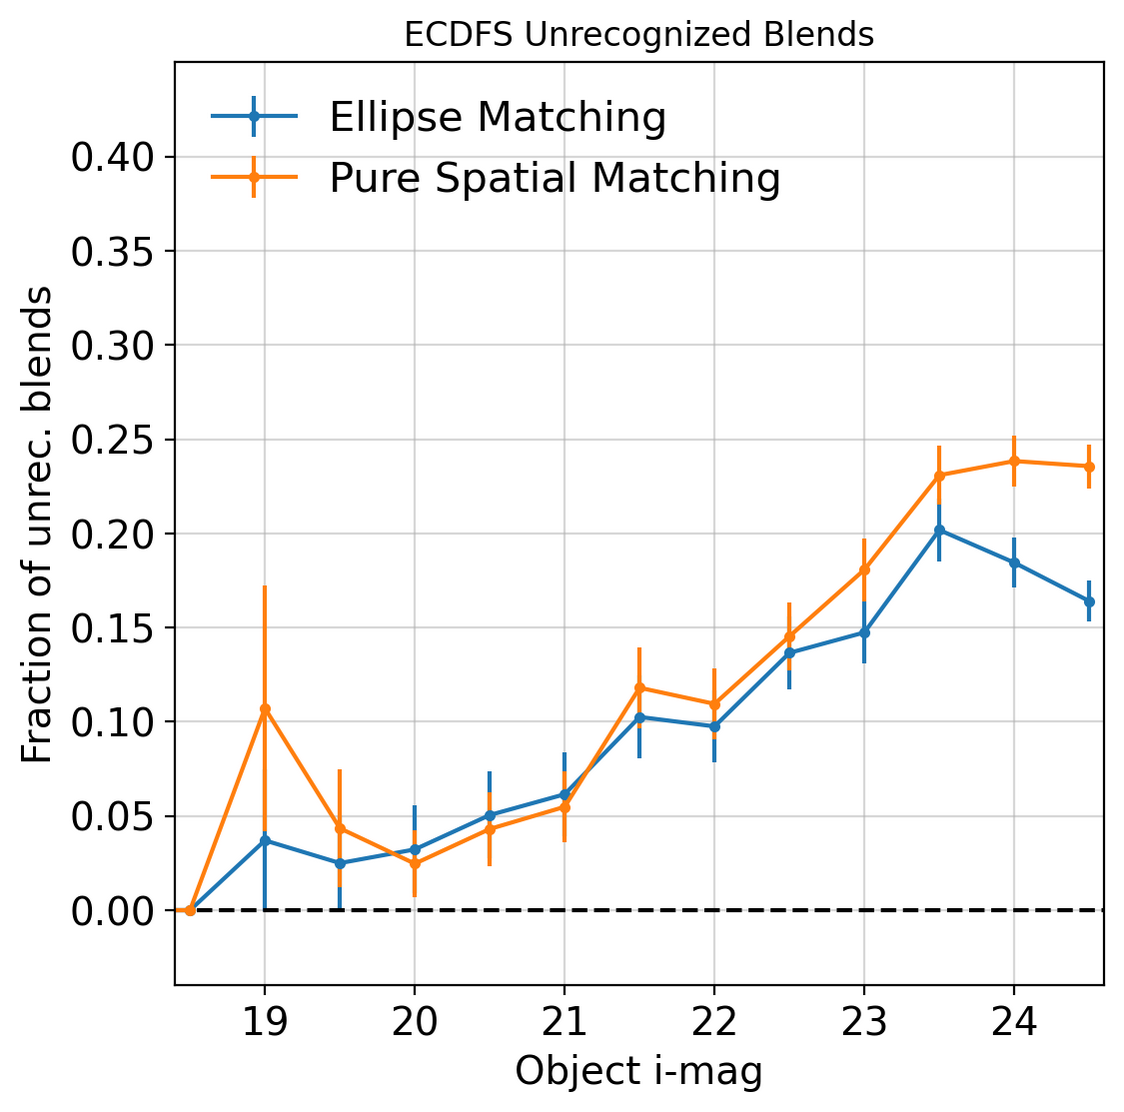

`A.search_around_sky(B)`
For each point in B, find all the neighbors that exist in A

In [10]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

def local_density_search_astropy(ground_cat, space_cat, search_radius_arcsec=5.0):
    """
    Use astropy's search_around_sky for proper spherical geometry
    """
    # Create SkyCoord objects
    ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values * u.deg, 
                            dec=ground_cat['coord_dec'].values * u.deg)
    space_coords = SkyCoord(ra=space_cat['RA'].values * u.deg, 
                           dec=space_cat['DEC'].values * u.deg)
    
    search_radius = search_radius_arcsec * u.arcsec
    
    # Count ground objects around each ground object
    print("Counting ground objects around each ground detection...")
    idx_ground, idx_self_ground, d2d_ground, d3d_ground = ground_coords.search_around_sky(
        ground_coords, search_radius
    )
    
    # Count occurrences of each ground object index
    N_g_counts = np.bincount(idx_ground, minlength=len(ground_coords))
    
    # Count space objects around each ground object  
    print("Counting space objects around each ground detection...")
    idx_ground_space, idx_space, d2d_space, d3d_space = space_coords.search_around_sky(
        ground_coords, search_radius
    )
    
    # Count occurrences of each ground object index
    N_s_counts = np.bincount(idx_ground_space, minlength=len(ground_coords))
    
    # Add counts to ground catalog
    ground_cat_with_counts = ground_cat.copy()
    ground_cat_with_counts['N_g'] = N_g_counts
    ground_cat_with_counts['N_s'] = N_s_counts
    
    return ground_cat_with_counts

def identify_candidate_blends_astropy(ground_cat_with_counts):
    """
    Identify candidate unrecognized blends using condition N_s > N_g
    This implements step 6 from the technical note.
    """
    ground_cat_with_counts['is_candidate_blend'] = (
        ground_cat_with_counts['N_s'] > ground_cat_with_counts['N_g']
    )
    
    print(f"Found {ground_cat_with_counts['is_candidate_blend'].sum()} candidate unrecognized blends")
    
    return ground_cat_with_counts

def apply_magnitude_refinement_astropy(ground_cat_with_counts, space_cat, 
                                     search_radius_arcsec=5.0, m_s=26.5, delta_mag_limit=2.0):
    """
    Apply magnitude cuts using astropy for spatial searching
    """
    ground_coords = SkyCoord(ra=ground_cat_with_counts['coord_ra'].values * u.deg, 
                            dec=ground_cat_with_counts['coord_dec'].values * u.deg)
    space_coords = SkyCoord(ra=space_cat['RA'].values * u.deg, 
                           dec=space_cat['DEC'].values * u.deg)
    
    search_radius = search_radius_arcsec * u.arcsec
    
    # Find all space objects around each ground object
    idx_ground, idx_space, d2d, d3d = space_coords.search_around_sky(
        ground_coords, search_radius
    )
    
    # Group space matches by ground object
    matches_df = pd.DataFrame({
        'ground_idx': idx_ground,
        'space_idx': idx_space
    })
    
    grouped_matches = matches_df.groupby('ground_idx')
    
    def count_surviving_matches_astropy(group):
        space_idxs = group['space_idx'].values
        space_mags = space_cat['mag_F814W'].iloc[space_idxs]
        
        # Remove NaN magnitudes
        space_mags = space_mags.dropna()
        
        if len(space_mags) <= 1:
            return False
            
        # Apply magnitude cuts
        if not (space_mags < m_s).all():
            return False
            
        if (space_mags.max() - space_mags.min()) >= delta_mag_limit:
            return False
            
        return True
    
    # Apply refinement to candidate blends only
    candidate_mask = ground_cat_with_counts['is_candidate_blend']
    final_blend_flags = np.zeros(len(ground_cat_with_counts), dtype=bool)
    
    # Only process candidate blends
    candidate_indices = ground_cat_with_counts[candidate_mask].index
    
    for idx in candidate_indices:
        if idx in grouped_matches.groups:
            group = grouped_matches.get_group(idx)
            final_blend_flags[idx] = count_surviving_matches_astropy(group)
    
    ground_cat_with_counts['is_final_blend'] = final_blend_flags
    
    final_blends = ground_cat_with_counts['is_final_blend'].sum()
    print(f"After magnitude cuts: {final_blends} final unrecognized blends")
    
    return ground_cat_with_counts

# Complete workflow using astropy tools:
def find_unrecognized_blends_astropy(ground_cat, space_cat, search_radius_arcsec=5.0, 
                                   m_s=26.5, delta_mag_limit=2.0):
    """
    Complete implementation of the technical note's spatial matching method using astropy
    """
    print("Step 1-2: Computing local density counts...")
    ground_with_counts = local_density_search_astropy(ground_cat, space_cat, search_radius_arcsec)
    
    print("Step 6: Identifying candidate blends...")
    ground_with_blends = identify_candidate_blends_astropy(ground_with_counts)
    
    print("Applying magnitude refinement cuts...")
    ground_final = apply_magnitude_refinement_astropy(ground_with_blends, space_cat, 
                                                    search_radius_arcsec, m_s, delta_mag_limit)
    
    return ground_final

In [15]:
ground_cat_final = find_unrecognized_blends_astropy(ground_cat, space_cat, 
                                                  search_radius_arcsec=5.0, 
                                                  m_s=26.5, 
                                                  delta_mag_limit=5.0)

Step 1-2: Computing local density counts...
Counting ground objects around each ground detection...
Counting space objects around each ground detection...
Step 6: Identifying candidate blends...
Found 12539 candidate unrecognized blends
Applying magnitude refinement cuts...
After magnitude cuts: 772 final unrecognized blends


For analysis (mag_i <= 24.5): 8089 objects
Unrecognized blends in analysis range: 378

Blend Statistics by Magnitude Bin:
Mag Bin | N_blends | N_total | Fraction | Error
--------------------------------------------------
18.25 |        0 |      26 | 0.0000 | 0.0000
18.75 |        0 |      61 | 0.0000 | 0.0000
19.25 |        4 |      44 | 0.0909 | 0.0433
19.75 |        0 |      79 | 0.0000 | 0.0000
20.25 |        4 |     128 | 0.0312 | 0.0154
20.75 |        8 |     185 | 0.0432 | 0.0150
21.25 |       16 |     270 | 0.0593 | 0.0144
21.75 |       35 |     448 | 0.0781 | 0.0127
22.25 |       38 |     576 | 0.0660 | 0.0103
22.75 |       50 |     826 | 0.0605 | 0.0083
23.25 |       58 |    1190 | 0.0487 | 0.0062
23.75 |       77 |    1780 | 0.0433 | 0.0048
24.25 |       88 |    2476 | 0.0355 | 0.0037


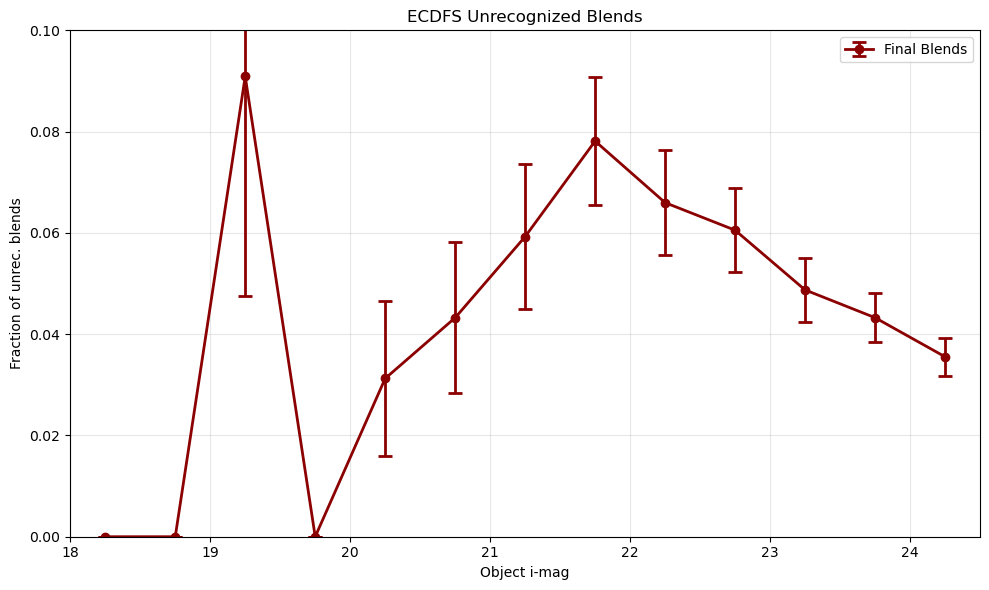

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_blend_fraction_by_magnitude(ground_cat_final, mag_column='mag_i', 
                                        mag_min=18.0, mag_max=24.5, bin_width=0.5):
    """
    Calculate unrecognized blend fraction as a function of magnitude
    """
    # Filter for analysis range
    analysis_mask = (ground_cat_final[mag_column] <= mag_max) & (ground_cat_final[mag_column] >= mag_min)
    ground_analysis = ground_cat_final[analysis_mask].copy()
    
    print(f"For analysis ({mag_column} <= {mag_max}): {len(ground_analysis)} objects")
    print(f"Unrecognized blends in analysis range: {ground_analysis['is_final_blend'].sum()}")
    
    # Create magnitude bins
    bin_edges = np.arange(mag_min, mag_max + bin_width, bin_width)
    bin_centers = bin_edges[:-1] + bin_width/2
    
    # Calculate fraction in each bin
    fractions = []
    errors = []
    n_blends_list = []
    n_total_list = []
    
    print("\nBlend Statistics by Magnitude Bin:")
    print("Mag Bin | N_blends | N_total | Fraction | Error")
    print("-" * 50)
    
    for i in range(len(bin_edges)-1):
        # Objects in this magnitude bin
        bin_mask = ((ground_analysis[mag_column] >= bin_edges[i]) & 
                   (ground_analysis[mag_column] < bin_edges[i+1]))
        
        bin_objects = ground_analysis[bin_mask]
        n_total = len(bin_objects)
        n_blends = bin_objects['is_final_blend'].sum()
        
        if n_total > 0:
            fraction = n_blends / n_total
            # Binomial error calculation
            error = np.sqrt(fraction * (1 - fraction) / n_total) if n_total > 0 else 0
        else:
            fraction = 0
            error = 0
        
        fractions.append(fraction)
        errors.append(error)
        n_blends_list.append(n_blends)
        n_total_list.append(n_total)
        
        print(f"{bin_centers[i]:5.2f} | {n_blends:8d} | {n_total:7d} | {fraction:6.4f} | {error:6.4f}")
    
    return bin_centers, fractions, errors, n_blends_list, n_total_list

def plot_blend_fraction(bin_centers, fractions, errors, title="ECDFS Unrecognized Blends"):
    """
    Plot the unrecognized blend fraction vs magnitude
    """
    plt.figure(figsize=(10, 6))
    plt.errorbar(bin_centers, fractions, yerr=errors, 
                marker='o', capsize=5, capthick=2, linewidth=2,
                label='Final Blends', color='darkred')
    
    plt.xlabel('Object i-mag')
    plt.ylabel('Fraction of unrec. blends')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Set reasonable axis limits
    plt.xlim(18, 24.5)
    plt.ylim(0, max(fractions) * 1.1)
    
    plt.tight_layout()
    plt.show()

bin_centers, fractions, errors, n_blends, n_total = calculate_blend_fraction_by_magnitude(
    ground_cat_final, mag_column='mag_i', mag_min=18.0, mag_max=24.5, bin_width=0.5
)

plot_blend_fraction(bin_centers, fractions, errors)

In [50]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
from astropy.coordinates import search_around_sky

# Load catalogs (replace with your file paths/names)
# Assume groundcat and spacecat are pandas DataFrames with 'ra', 'dec', 'mag' columns, etc.
# groundcat = pd.read_json("lsstdets_hst.json")
# spacecat  = pd.read_json("hstdets_lsst.json")

# Set up positions
ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values*u.deg, dec=ground_cat['coord_dec'].values*u.deg)
space_coords  = SkyCoord(ra=space_cat['RA'].values*u.deg,  dec=space_cat['DEC'].values*u.deg)
search_radius = 2.0 * u.arcsec  # candidate_boost_factor=2, as in the tech note

# --- Step 1: Ground Catalog Self-Match ---
idx_g1, idx_g2, sep2d_g, _ = search_around_sky(ground_coords, ground_coords, seplimit=search_radius)

# Create ground neighbor counts: count for each LSST object how many LSST objects are within r arcsec
ground_neighbors = pd.Series(idx_g2).groupby(idx_g1).count()  # idx_g1 is the index of the "original" ground object

# --- Step 2: Space Catalog Crossmatch ---
idx_g, idx_s, sep2d, _ = search_around_sky(ground_coords, space_coords, seplimit=search_radius)

# Build DataFrame for cross-matches
crossmatch_df = pd.DataFrame({
    'ground_idx': idx_g,
    'space_idx': idx_s,
    'sep': sep2d.arcsec
})
# Join magnitudes and any other relevant columns
crossmatch_df = crossmatch_df.join(ground_cat.iloc[idx_g].reset_index(drop=True), rsuffix="_g")
crossmatch_df = crossmatch_df.join(space_cat.iloc[idx_s].reset_index(drop=True), rsuffix="_s")

# --- Step 3: Apply required magnitude and overlap cuts on the space matches ---
m_s = 26.5  # faint mag cut for space matches (HST F814W completeness limit)
m_delta = 2.0  # delta mag cut

# def apply_magnitude_cuts(group):
#     mags = group['mag_F814W']  # Or adjust for your HST mag column
#     # Remove objects fainter than m_s
#     survived = group[mags < m_s]
#     if survived.empty:
#         return pd.Series({'n_space': 0, 'n_survived': 0, 'delta_mag': np.nan})
#     delta_mag = survived['mag_F814W'].max() - survived['mag_F814W'].min()
#     # delta_mag cut
#     survived = survived[delta_mag < m_delta]
#     return pd.Series({'n_space': len(group), 'n_survived': len(survived), 'delta_mag': delta_mag})

def apply_magnitude_cuts(group):
    mags = group['mag_F814W']
    # Remove objects fainter than m_s
    survived = group[mags < m_s]
    if survived.empty:
        return pd.Series({'n_space': len(group), 'n_survived': 0, 'delta_mag': np.nan})
    delta_mag = survived['mag_F814W'].max() - survived['mag_F814W'].min()
    # delta_mag cut: if delta is too large, treat as zero matches survive
    if delta_mag < m_delta:
        n_survived = len(survived)
    else:
        n_survived = 0
    return pd.Series({'n_space': len(group), 'n_survived': n_survived, 'delta_mag': delta_mag})


# Group matches by ground_idx
space_match_stats = crossmatch_df.groupby('ground_idx').apply(apply_magnitude_cuts)

# Join ground neighbor count and survived space matches for each original LSST object
result = pd.DataFrame({
    'ground_neighbors': ground_neighbors,    # total LSST within r arcsec
    'space_matches': space_match_stats['n_survived'].fillna(0).astype(int) # survived HST matches
})

# --- Step 4: Classification per tech note logic ---
def classify(row):
    # Only if the *final* (post-cut) number of space matches exceeds ground neighbors, it's an unrecognized blend
    if row['space_matches'] > row['ground_neighbors']:
        return 'candidate_unrecognized_blend'
    elif row['space_matches'] <= row['ground_neighbors']:
        return 'recognized_blend_or_spurious'
    else:
        return 'unclassified'
result['blend_type'] = result.apply(classify, axis=1)

In [10]:
from astropy.coordinates import SkyCoord
from astropy import units as u

ground_coords = SkyCoord(ra=ground_cat['coord_ra'].values*u.deg, dec=ground_cat['coord_dec'].values*u.deg)
space_coords = SkyCoord(ra=space_cat['RA'].values*u.deg, dec=space_cat['DEC'].values*u.deg)
search_radius = 2.0 * u.arcsec
# search space catalog for objs that are around ground coords
idx_ground, idx_space, _, _ = space_coords.search_around_sky(ground_coords, seplimit=search_radius)
# candidate matches
matches_df = pd.DataFrame({
    'ground_idx': idx_ground,
    'space_idx': idx_space
})
print(f"Found {len(matches_df)} total cross-matches.")

Found 24735 total cross-matches.


In [11]:
matches_df

,ground_idx,space_idx
0,1,2
1,1,3
2,2,18
3,3,6
4,3,10
...,...,...
24730,27903,23665
24731,27905,23610
24732,27905,23731
24733,27908,23623


In [12]:
print("Applying mag cuts to refine blends...")
m_s = 26.5
delta_mag_limit = 2.0
# group matches by each ground object
grouped_matches = matches_df.groupby('ground_idx')

# apply this function to each group of space matches
def count_surviving_matches(space_idxs):
    # mags of all space objs in group
    space_mags = space_cat['mag_F814W'].loc[space_idxs.values]
# # #     # first cut: All space objects must be brighter than m_s
#     if not (space_mags < m_s).all(): 
#         return 0 # candidate fails first cut

#     # second cut: mag diff must be less than delta_mag
#     if len(space_mags) > 1:
#         delta_mag = space_mags.max() - space_mags.min()
#         if delta_mag >= delta_mag_limit:
#             return 0 # candidate fails second cut

#     # return the number of surviving objs that passed cuts
    return len(space_mags)

# get final count of valid matches for each ground obj
final_match_counts = grouped_matches['space_idx'].apply(count_surviving_matches)
# final counts to ground catalog
ground_cat['n_final_matches'] = 0
ground_cat.loc[final_match_counts.index, 'n_final_matches'] = final_match_counts

Applying mag cuts to refine blends...


## Unrecognized Blend Fraction

In [52]:
(result.loc[sel, 'blend_type'] == 'candidate_unrecognized_blend').sum()

333

Total (mag_i ≤ 24.5): 8362
Unrecognized blends: 697
Blend fraction: 0.083


(18.0, 24.5)

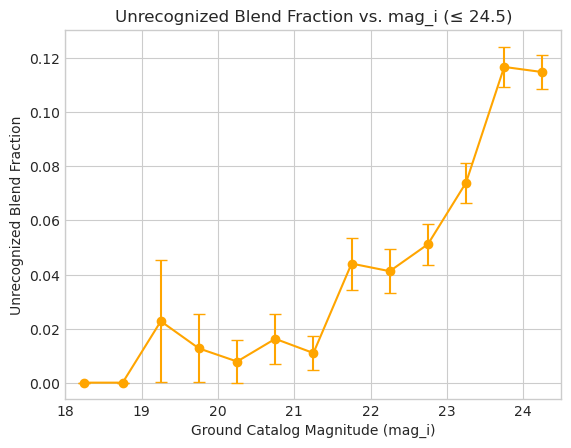

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose your DataFrame 'result' contains ground object info and your classification (blend_type)
# Also assume ground_cat has the magnitude column, e.g., 'mag_i' for i-band
# result = result.join(ground_cat['mag_i'])

mag_cut = 24.5
result_cut = result[result['mag_i'] <= mag_cut]
n_total = len(result_cut)
n_blends = (result_cut['blend_type'] == 'candidate_unrecognized_blend').sum()
blend_fraction = n_blends / n_total if n_total > 0 else np.nan
print(f"Total (mag_i ≤ {mag_cut}): {n_total}")
print(f"Unrecognized blends: {n_blends}")
print(f"Blend fraction: {blend_fraction:.3f}")

mag_bins = np.arange(18, 25, 0.5)    # goes to 24.5 maximum
mag_centers = 0.5 * (mag_bins[1:] + mag_bins[:-1])

blend_fractions = []
blend_errors = []
for i in range(len(mag_bins)-1):
    sel = (result_cut['mag_i'] > mag_bins[i]) & (result_cut['mag_i'] <= mag_bins[i+1])
    n_total_bin = sel.sum()
    n_blends_bin = (result_cut.loc[sel, 'blend_type'] == 'candidate_unrecognized_blend').sum()
    frac = n_blends_bin / n_total_bin if n_total_bin > 0 else np.nan
    err = np.sqrt(frac * (1 - frac) / n_total_bin) if n_total_bin > 0 else np.nan
    blend_fractions.append(frac)
    blend_errors.append(err)

import matplotlib.pyplot as plt
plt.errorbar(mag_centers, blend_fractions, yerr=blend_errors, fmt='o-', color='orange', capsize=4)
plt.xlabel('Ground Catalog Magnitude (mag_i)')
plt.ylabel('Unrecognized Blend Fraction')
plt.title('Unrecognized Blend Fraction vs. mag_i (≤ 24.5)')
plt.grid(True)
# plt.ylim(-0.02, 0.45)
plt.xlim(mag_bins[0], mag_bins[-1])

In [48]:
for c, n_bl, n_tot, frac in zip(mag_centers, n_blends_list, n_total_list, blend_fractions):
    print(f"Mag {c:.2f}: N_blend={n_bl}, N_total={n_tot}, Fraction={frac:.3f}")


Mag 18.25: N_blend=0, N_total=26, Fraction=0.000
Mag 18.75: N_blend=0, N_total=61, Fraction=0.000
Mag 19.25: N_blend=1, N_total=44, Fraction=0.023
Mag 19.75: N_blend=1, N_total=79, Fraction=0.013
Mag 20.25: N_blend=1, N_total=128, Fraction=0.008
Mag 20.75: N_blend=3, N_total=185, Fraction=0.016
Mag 21.25: N_blend=3, N_total=274, Fraction=0.011
Mag 21.75: N_blend=20, N_total=454, Fraction=0.044
Mag 22.25: N_blend=24, N_total=582, Fraction=0.041
Mag 22.75: N_blend=43, N_total=840, Fraction=0.051
Mag 23.25: N_blend=91, N_total=1230, Fraction=0.074
Mag 23.75: N_blend=214, N_total=1832, Fraction=0.117
Mag 24.25: N_blend=296, N_total=2576, Fraction=0.115
Mag 24.75: N_blend=333, N_total=3524, Fraction=0.094


In [17]:
# unrec blend means there's more than one surviving match
ground_cat['is_blend'] = ground_cat['n_final_matches'] > 1
num_final_blends = ground_cat['is_blend'].sum()
print(f"Identified {num_final_blends} final unrecognized blends after applying cuts.") 
# 1593 are just galaxies (ground_cat[ground_cat['refExtendedness'] == 1]['is_blend'].sum())

Identified 6488 final unrecognized blends after applying cuts.


In [18]:
ground_cat_analysis = ground_cat[(ground_cat['mag_i'] <= 24.5)].copy()
print(f"For analysis (mag_i <= 24.5): {len(ground_cat_analysis)} objects")
print(f"Unrecognized blends in analysis range: {ground_cat_analysis['is_blend'].sum()}")

For analysis (mag_i <= 24.5): 8140 objects
Unrecognized blends in analysis range: 2078


In [70]:
ground_cat_analysis = ground_cat[(ground_cat['mag_i'] <= 24.5) & (ground_cat['refExtendedness'] == 1)].copy()
print(f"For analysis (mag_i <= 24.5): {len(ground_cat_analysis)} objects")
print(f"Unrecognized blends in analysis range: {ground_cat_analysis['is_blend'].sum()}")

For analysis (mag_i <= 24.5): 7350 objects
Unrecognized blends in analysis range: 1923


In [20]:
# unrec blend means there's more than one surviving match
ground_cat['is_blend'] = ground_cat['n_final_matches'] > 1
num_final_blends = ground_cat['is_blend'].sum()
print(f"Identified {num_final_blends} final unrecognized blends after applying cuts.") 
# 1593 are just galaxies (ground_cat[ground_cat['refExtendedness'] == 1]['is_blend'].sum())

Identified 1990 final unrecognized blends after applying cuts.


In [15]:
ground_cat_analysis = ground_cat[(ground_cat['mag_i'] <= 24.5)].copy()
print(f"For analysis (mag_i <= 24.5): {len(ground_cat_analysis)} objects")
print(f"Unrecognized blends in analysis range: {ground_cat_analysis['is_blend'].sum()}")

For analysis (mag_i <= 24.5): 8140 objects
Unrecognized blends in analysis range: 744


## Plot from Tech Note (Unrec blend frac vs mag)

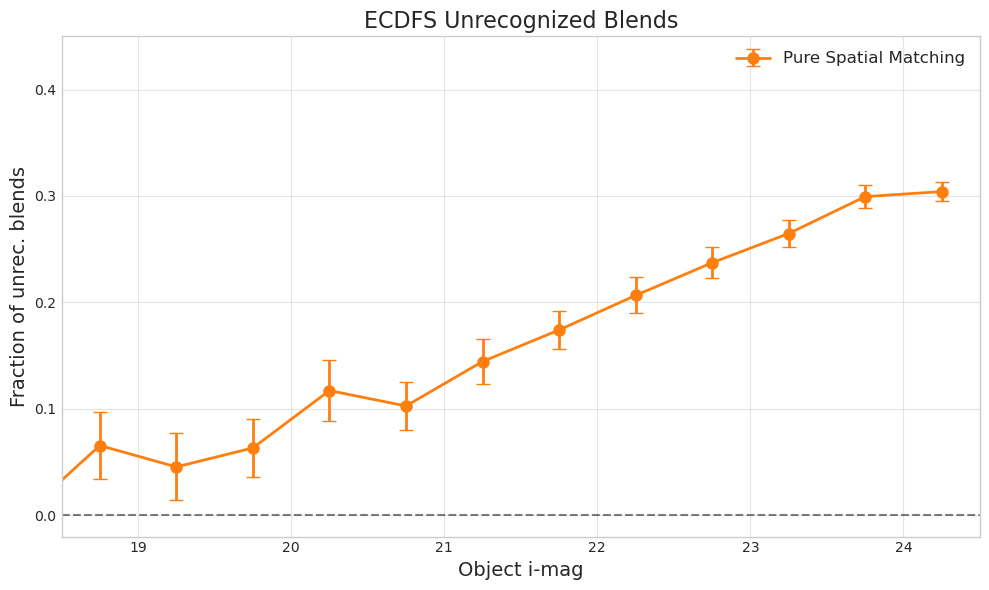

In [93]:
mag_bins = np.arange(18.0, 25.5, 0.5)
bin_centers = 0.5 * (mag_bins[:-1] + mag_bins[1:])
# blend fraction per bin
blend_fractions = []
blend_errors = []
valid_bins = []
n_blends_list = []
n_total_list = []

for i in range(len(mag_bins)-1):
    bin_mask = (ground_cat_analysis['mag_i'] >= mag_bins[i]) & \
               (ground_cat_analysis['mag_i'] < mag_bins[i+1])
    n_total = bin_mask.sum()
    
    if n_total > 0:
        n_blends = ground_cat_analysis.loc[bin_mask, 'is_blend'].sum()
        fraction = n_blends / n_total
        # binomial error
        error = np.sqrt(fraction * (1 - fraction) / n_total)
        blend_fractions.append(fraction)
        blend_errors.append(error)
        valid_bins.append(bin_centers[i])
        n_blends_list.append(n_blends)
        n_total_list.append(n_total)

plt.figure(figsize=(10, 6))
plt.errorbar(valid_bins, blend_fractions, yerr=blend_errors, 
             fmt='o-', capsize=5, label='Pure Spatial Matching', 
             color='tab:orange', linewidth=2, markersize=8)

plt.xlabel('Object i-mag', fontsize=14)
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=16)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=12)

plt.ylim(-0.02, 0.45)
plt.xlim(18.5, 24.5)

# horizontal line at 0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()

In [72]:
print("Blend Statistics by Magnitude Bin:")
print("Mag Bin | N_blends | N_total | Fraction | Error")
print("-" * 50)
for i in range(len(valid_bins)):
    print(f"{valid_bins[i]:.2f} | {n_blends_list[i]:8d} | {n_total_list[i]:7d} | "
          f"{blend_fractions[i]:.4f} | {blend_errors[i]:.4f}")

Blend Statistics by Magnitude Bin:
Mag Bin | N_blends | N_total | Fraction | Error
--------------------------------------------------
18.25 |        0 |      14 | 0.0000 | 0.0000
18.75 |        1 |      35 | 0.0286 | 0.0282
19.25 |        1 |      26 | 0.0385 | 0.0377
19.75 |        5 |      51 | 0.0980 | 0.0416
20.25 |       11 |      88 | 0.1250 | 0.0353
20.75 |       13 |     145 | 0.0897 | 0.0237
21.25 |       30 |     222 | 0.1351 | 0.0229
21.75 |       68 |     376 | 0.1809 | 0.0198
22.25 |      106 |     502 | 0.2112 | 0.0182
22.75 |      181 |     761 | 0.2378 | 0.0154
23.25 |      300 |    1126 | 0.2664 | 0.0132
23.75 |      507 |    1685 | 0.3009 | 0.0112
24.25 |      700 |    2307 | 0.3034 | 0.0096


In [ ]:
array([0.        , 0.06557377, 0.04545455, 0.06329114, 0.1171875 ,
       0.1027027 , 0.14444444, 0.17410714, 0.20659722, 0.23728814,
       0.26470588, 0.2994382 , 0.30411955])

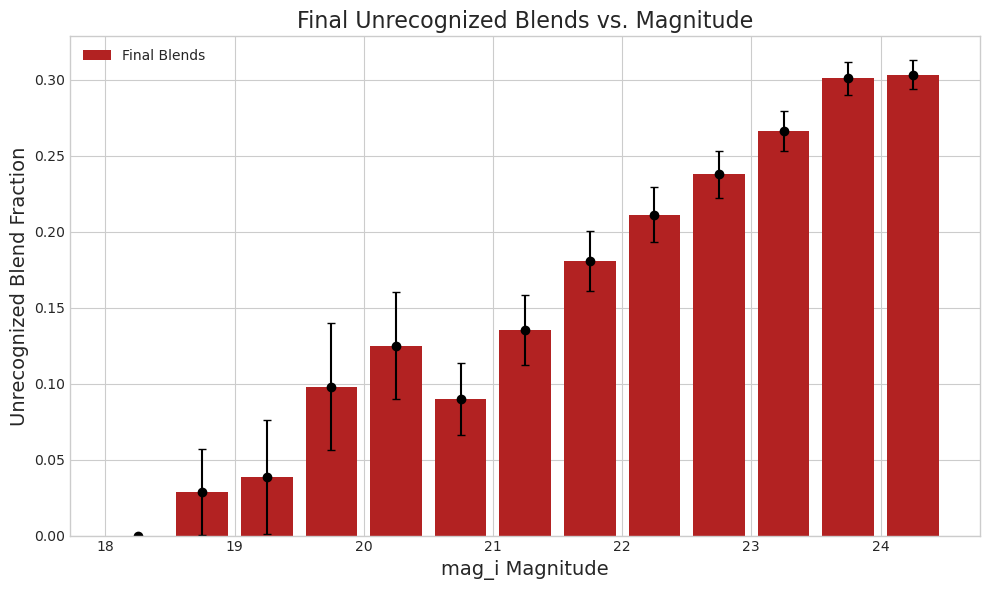

In [64]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot blend fractions as a bar chart
ax.bar(valid_bins, blend_fractions, width=0.4, label='Final Blends', color='firebrick', align='center')

# Optionally overlay error bars
ax.errorbar(valid_bins, blend_fractions, yerr=blend_errors, fmt='o', color='black', capsize=3)

# Customize plot
ax.set_xlabel('mag_i Magnitude', fontsize=14)
ax.set_ylabel('Unrecognized Blend Fraction', fontsize=14)
ax.set_title('Final Unrecognized Blends vs. Magnitude', fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()


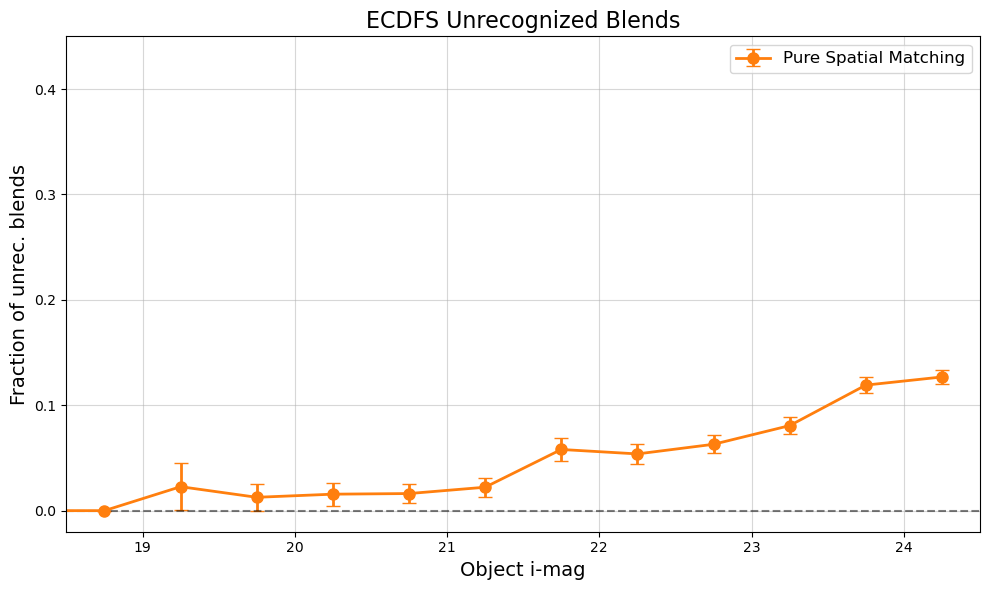

In [16]:
mag_bins = np.arange(18.0, 25.5, 0.5)
bin_centers = 0.5 * (mag_bins[:-1] + mag_bins[1:])
# blend fraction per bin
blend_fractions = []
blend_errors = []
valid_bins = []
n_blends_list = []
n_total_list = []

for i in range(len(mag_bins)-1):
    bin_mask = (ground_cat_analysis['mag_i'] >= mag_bins[i]) & \
               (ground_cat_analysis['mag_i'] < mag_bins[i+1])
    n_total = bin_mask.sum()
    
    if n_total > 0:
        n_blends = ground_cat_analysis.loc[bin_mask, 'is_blend'].sum()
        fraction = n_blends / n_total
        # binomial error
        error = np.sqrt(fraction * (1 - fraction) / n_total)
        blend_fractions.append(fraction)
        blend_errors.append(error)
        valid_bins.append(bin_centers[i])
        n_blends_list.append(n_blends)
        n_total_list.append(n_total)

plt.figure(figsize=(10, 6))
plt.errorbar(valid_bins, blend_fractions, yerr=blend_errors, 
             fmt='o-', capsize=5, label='Pure Spatial Matching', 
             color='tab:orange', linewidth=2, markersize=8)

plt.xlabel('Object i-mag', fontsize=14)
plt.ylabel('Fraction of unrec. blends', fontsize=14)
plt.title('ECDFS Unrecognized Blends', fontsize=16)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=12)

plt.ylim(-0.02, 0.45)
plt.xlim(18.5, 24.5)

# horizontal line at 0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()

In [19]:
print("Blend Statistics by Magnitude Bin:")
print("Mag Bin | N_blends | N_total | Fraction | Error")
print("-" * 50)
for i in range(len(valid_bins)):
    print(f"{valid_bins[i]:.2f} | {n_blends_list[i]:8d} | {n_total_list[i]:7d} | "
          f"{blend_fractions[i]:.4f} | {blend_errors[i]:.4f}")

Blend Statistics by Magnitude Bin:
Mag Bin | N_blends | N_total | Fraction | Error
--------------------------------------------------
18.25 |        0 |      26 | 0.0000 | 0.0000
18.75 |        0 |      61 | 0.0000 | 0.0000
19.25 |        1 |      44 | 0.0227 | 0.0225
19.75 |        1 |      79 | 0.0127 | 0.0126
20.25 |        2 |     128 | 0.0156 | 0.0110
20.75 |        3 |     185 | 0.0162 | 0.0093
21.25 |        6 |     270 | 0.0222 | 0.0090
21.75 |       26 |     448 | 0.0580 | 0.0110
22.25 |       31 |     576 | 0.0538 | 0.0094
22.75 |       52 |     826 | 0.0630 | 0.0085
23.25 |       96 |    1190 | 0.0807 | 0.0079
23.75 |      212 |    1780 | 0.1191 | 0.0077
24.25 |      314 |    2476 | 0.1268 | 0.0067


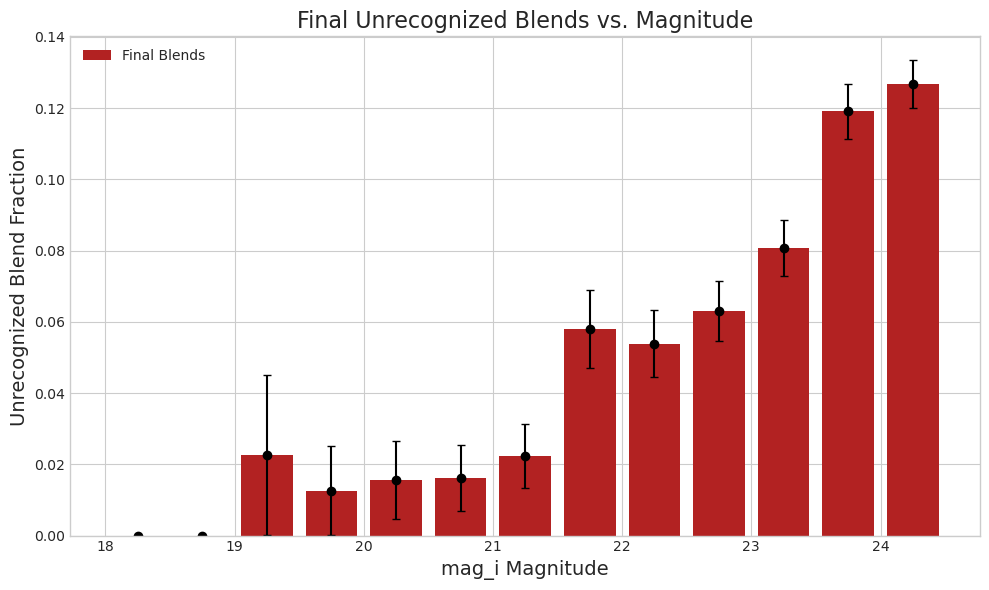

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot blend fractions as a bar chart
ax.bar(valid_bins, blend_fractions, width=0.4, label='Final Blends', color='firebrick', align='center')

# Optionally overlay error bars
ax.errorbar(valid_bins, blend_fractions, yerr=blend_errors, fmt='o', color='black', capsize=3)

# Customize plot
ax.set_xlabel('mag_i Magnitude', fontsize=14)
ax.set_ylabel('Unrecognized Blend Fraction', fontsize=14)
ax.set_title('Final Unrecognized Blends vs. Magnitude', fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()


# Det Completeness

In [26]:
def calc_det_comp(ground_cat, space_cat, max_sep=2.0*u.arcsec, ground_coord_ra='coord_ra', ground_coord_dec='coord_dec'):
    """
    Which space objects are detected by ground cat using 1-to-1 matching?
    Match ground catalog to space catalog (ground -> space)
    """
    if len(ground_cat) == 0 or len(space_cat) == 0:
        return np.zeros(len(space_cat), dtype=bool)
    
    gcoord = SkyCoord(ground_cat[ground_coord_ra].values*u.deg,
                      ground_cat[ground_coord_dec].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)
    
    # matching each ground object to nearest space object
    idx_ground, d2d, _ = gcoord.match_to_catalog_sky(scoord)
    # keep matches within search radius
    good_sep = d2d <= max_sep    
    # How many space (truth) objects match to each ground (det) object?
    unique_space, space_counts = np.unique(idx_ground[good_sep], return_counts=True)
    good_space = unique_space[space_counts == 1]  # keeping only 1-to-1 matches

    print(f"Found {len(good_space)} 1-1 matched pairs out of {len(space_cat)} space objects")
    
    # Mark which space objects have a valid 1-to-1 match
    space_detected = np.zeros(len(space_cat), dtype=bool)
    space_detected[good_space] = True
    
    return space_detected

def comp_by_mag(space_cat, space_detected, mag_col='mag_F814W',
                             mag_bins=None, min_per_bin=10):
    """
    Calculate detection completeness as a function of mag.
    
    Parameters:
    -----------
    space_cat : DataFrame
        Space catalog
    space_detected : boolean array
        Detection flag for each space object
    mag_col : str
        Name of mag column to use
    mag_bins : array-like or None
        mag bin edges. If None, auto-generate
    min_per_bin : int
        Minimum objects per bin for valid comp
    
    Returns:
    --------
    mag_centers : array
        Center of each mag bin
    comp : array
        Detection comp fraction for each bin
    counts : array
        Total number of space objects in each bin
    detected_counts : array
        Number of detected space objects in each bin
    """
    mags = space_cat[mag_col].values
    
    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)
    
    mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
    comps = []
    counts = []
    detected_counts = []
    
    for i in range(len(mag_bins) - 1):
        in_bin = (mags >= mag_bins[i]) & (mags < mag_bins[i+1])
        n_total = np.sum(in_bin)
        n_detected = np.sum(in_bin & space_detected)
        
        if n_total >= min_per_bin:
            comp = n_detected / n_total
        else:
            comp = np.nan
        
        comps.append(comp)
        counts.append(n_total)
        detected_counts.append(n_detected)
    
    return mag_centers, np.array(comps), np.array(counts), np.array(detected_counts)


def bootstrap_comp(space_cat, space_detected, n_bootstrap=100,
                   mag_col='mag_F814W', mag_bins=None, seed=42):
    """
    Calculates bootstrap CIs by resampling the matching results.
    """
    np.random.seed(seed)
    n_space = len(space_cat)

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    overall_samples = []
    binned_samples = []

    for i in range(n_bootstrap):
        if i % 100 == 0:
            print(f"Bootstrap sample {i}/{n_bootstrap}")
        
        # 1. Resample the INDICES of the original catalog
        idx = np.random.choice(n_space, n_space, replace=True)

        # 2. Create a bootstrap sample from the ORIGINAL results using these indices
        space_boot_cat = space_cat.iloc[idx].reset_index(drop=True)
        space_boot_detected = space_detected[idx]  # Resample the boolean flags

        # 3. Calculate overall completeness for this bootstrap sample
        overall_comp = np.sum(space_boot_detected) / len(space_boot_detected)
        overall_samples.append(overall_comp)

        # 4. Calculate binned completeness on the resampled results
        _, comp_boot, _, _ = comp_by_mag(
            space_boot_cat, space_boot_detected,
            mag_col=mag_col, mag_bins=mag_bins
        )
        binned_samples.append(comp_boot)

    return np.array(overall_samples), np.array(binned_samples)

def plot_comp(mag_centers, comp, space_cat, mag_bins, overall_comp,
                      errors_lower=None, errors_upper=None,
                      show_errors=True, error_style='bars',
                      show_distribution=True, mag_col='mag_F814W',
                      title='Detection Completeness',
                      save_path=None):
    """
    Plot detection completeness with optional error bars/bands and mag distribution.
    
    Parameters:
    -----------
    mag_centers : array
        mag bin centers
    comp : array
        comp values
    space_cat : DataFrame
        Space catalog for distribution
    errors_lower : array or None
        Lower error bounds
    errors_upper : array or None
        Upper error bounds
    show_errors : bool
        Whether to show error bars/bands
    error_style : str
        'bars' for error bars, 'bands' for shaded bands
    show_distribution : bool
        Whether to show mag distribution
    mag_col : str
        mag column name
    title : str
        Plot title
    save_path : str or None
        Path to save figure
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Main comp plot
    valid = ~np.isnan(comp)
    ax1.plot(mag_centers[valid], comp[valid], 'o-', color='green', 
             linewidth=2, markersize=6, label='LSST')
    
    # Add errors if requested
    if show_errors and errors_lower is not None and errors_upper is not None:
        if error_style == 'bars':
            # Error bars
            yerr_lower = comp - errors_lower
            yerr_upper = errors_upper - comp
            yerr = np.array([yerr_lower[valid], yerr_upper[valid]])
            ax1.errorbar(mag_centers[valid], comp[valid], 
                        yerr=yerr, fmt='none', color='green', 
                        capsize=3, alpha=0.5)
        elif error_style == 'bands':
            # Shaded bands
            ax1.fill_between(mag_centers[valid], errors_lower[valid], 
                           errors_upper[valid], alpha=0.3, color='green',
                           label='95% CI')
    
    ax1.set_xlabel('Mag (F814W)', fontsize=12)
    ax1.set_ylabel('Detection Completeness', fontsize=12)
    ax1.tick_params(axis='y')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title, fontsize=14)
    
    # Add mag distribution if requested
    if show_distribution:
        ax2 = ax1.twinx()
        
        # Create histogram
        mags = space_cat[mag_col].values
        mags_clean = mags[np.isfinite(mags)]
        
        # Use same bins as comp calculation
        counts, bins, patches = ax2.hist(mags_clean, bins=mag_bins, 
                                        color='gray', alpha=0.2, 
                                        edgecolor='gray', linewidth=0.5)
        
        ax2.set_ylabel('Number of Space Objects', fontsize=12, color='gray')
        ax2.set_yscale('log')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.set_ylim(1, np.max(counts) * 2)
    
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1, label='80% Completeness')
    ax1.axvline(x=26.4, color='black', linestyle='-', alpha=0.5, linewidth=1, label='5σ Limit (26.4)')
    
    # Add legend
    if show_errors and error_style == 'bands':
        ax1.legend(loc='lower left')
    else:
        ax1.legend(loc='lower left')
    
    # Add horizontal line at 80% comp
    
    # Add text box with overall comp
    # this overall comp (overall_comp = np.nanmean(comp[valid])) 
    # is misleading bc it's the unweighted avg of the binned completeness vals
    # simply adds up completeness % from each mag bin (61.1%, 44.4%, etc.) and divides by num of bins
    # misleading bc it gives same importance to the high-completeness bin with only 18 bright objects 
    # as it does to the low-completeness bin with over 4,200 faint objects. 
    # Since most of our objs are in lower-completeness bins, the true weighted average is much lower (35.9%)   
    textstr = f'Overall: {overall_comp:.1%}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    plt.tight_layout()
    
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches='tight')
def run_comp_analysis(ground_cat, space_cat, 
                             max_sep=2.0*u.arcsec,
                             mag_col='mag_F814W',
                             mag_bins=None,
                             n_bootstrap=100,
                             show_errors=True,
                             error_style='bands',
                             show_distribution=True,
                             confidence_level=0.95):
    print("Calculating detection completeness...")
    space_detected = calc_det_comp(ground_cat, space_cat)
    overall_completeness = np.sum(space_detected) / len(space_cat)
    print(f"Overall detection completeness: {overall_completeness:.1%}")
    # binned comp
    mag_centers, comps, counts, detected_counts = comp_by_mag(
        space_cat, space_detected, mag_col, mag_bins
    )
    print("\n------Completeness by mag--------")
    for i, (mc, comp, n, nd) in enumerate(zip(mag_centers, comps, counts, detected_counts)):
        if not np.isnan(comp):
            print(f"  {mag_bins[i]:.1f}-{mag_bins[i+1]:.1f}: "
                  f"{nd:4d}/{n:4d} = {comp:.1%}")

    # Bootstrap for errors
    errors_lower = None
    errors_upper = None
    overall_ci = None

    if show_errors and n_bootstrap > 0:
        print(f"\nRunning bootstrap with {n_bootstrap} samples...")
#         overall_samples, binned_samples = bootstrap_comp(
#             ground_cat, space_cat, n_bootstrap, max_sep, 
#             mag_col, mag_bins
#         )
        overall_samples, binned_samples = bootstrap_comp(
            space_cat, space_detected, n_bootstrap,
            mag_col, mag_bins
        )
        # conf intervals
        alpha = 1 - confidence_level
        lower_percentile = (alpha/2) * 100
        upper_percentile = (1 - alpha/2) * 100
        # overall CI
        overall_ci = np.percentile(overall_samples, [lower_percentile, upper_percentile])
        print(f"Overall completeness: {overall_completeness:.1%} "
              f"({overall_ci[0]:.1%}, {overall_ci[1]:.1%})")
        # binned CI
        errors_lower = np.nanpercentile(binned_samples, lower_percentile, axis=0)
        errors_upper = np.nanpercentile(binned_samples, upper_percentile, axis=0)
    
    plot_comp(mag_centers, comps, space_cat, mag_bins, overall_completeness,
                     errors_lower, errors_upper,
                     show_errors=show_errors and n_bootstrap > 0,
                     error_style=error_style,
                     show_distribution=show_distribution,
                     mag_col=mag_col)
    
    results = {
        'overall_completeness': overall_completeness,
        'overall_ci': overall_ci,
        'mag_centers': mag_centers,
        'completeness': comps,
        'counts': counts,
        'detected_counts': detected_counts,
        'errors_lower': errors_lower,
        'errors_upper': errors_upper,
        'space_detected': space_detected
    }
    
    return results

Calculating detection completeness...
Found 11553 1-1 matched pairs out of 16197 space objects
Overall detection completeness: 71.3%

------Completeness by mag--------
  18.0-18.5:   18/  18 = 100.0%
  18.5-19.0:   27/  27 = 100.0%
  19.0-19.5:   29/  29 = 100.0%
  19.5-20.0:   39/  39 = 100.0%
  20.0-20.5:   72/  78 = 92.3%
  20.5-21.0:   99/ 107 = 92.5%
  21.0-21.5:  153/ 172 = 89.0%
  21.5-22.0:  234/ 243 = 96.3%
  22.0-22.5:  299/ 320 = 93.4%
  22.5-23.0:  413/ 462 = 89.4%
  23.0-23.5:  598/ 674 = 88.7%
  23.5-24.0:  906/1035 = 87.5%
  24.0-24.5: 1183/1431 = 82.7%
  24.5-25.0: 1589/2011 = 79.0%
  25.0-25.5: 1993/2679 = 74.4%
  25.5-26.0: 2172/3485 = 62.3%
  26.0-26.5: 1714/3372 = 50.8%

Running bootstrap with 100 samples...
Bootstrap sample 0/100
Overall completeness: 71.3% (70.5%, 71.9%)

Final overall completeness: 71.3%
95% CI: (70.5%, 71.9%)


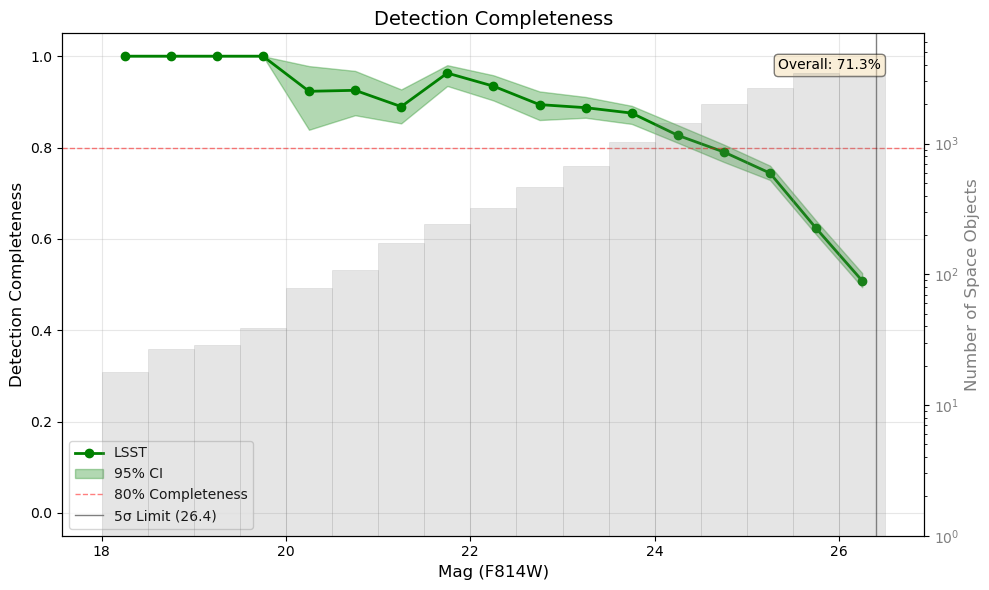

In [27]:
mag_bins = np.arange(18, 27, 0.5)
results = run_comp_analysis(
    ground_cat, 
    space_cat[space_cat['mag_F814W'] < 26.4],
    mag_col='mag_F814W',      # mag col in space cat
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=100,
    show_errors=True,             # show error bars/bands
    error_style='bands',          # 'bands' or 'bars'
    show_distribution=True,       # show magnitude distribution
    confidence_level=0.95         # 95% confidence intervals
)
# Access results
print(f"\nFinal overall completeness: {results['overall_completeness']:.1%}")
if results['overall_ci'] is not None:
    print(f"95% CI: ({results['overall_ci'][0]:.1%}, {results['overall_ci'][1]:.1%})")

# Det Purity

In [13]:
def find_purity_mask(ground_cat, space_cat, max_sep=2.0*u.arcsec,
                     ground_coord_ra='ra', ground_coord_dec='dec'):
    """
    Which ground detections are real? (Purity)
    Returns a boolean mask for the GROUND catalog
    """
    # basically the same as find_comp_mask but final step is diff
    if len(ground_cat) == 0 or len(space_cat) == 0:
        return np.zeros(len(ground_cat), dtype=bool)

    gcoord = SkyCoord(ground_cat[ground_coord_ra].values*u.deg,
                      ground_cat[ground_coord_dec].values*u.deg)
    scoord = SkyCoord(space_cat['RA'].values*u.deg,
                      space_cat['DEC'].values*u.deg)

    idx_ground, d2d, _ = gcoord.match_to_catalog_sky(scoord)
    good_sep = d2d <= max_sep
    
    unique_space, space_counts = np.unique(idx_ground[good_sep], return_counts=True)
    good_space_idxs = unique_space[space_counts == 1]
    # Mark which GROUND dets are part of a valid 1-to-1 match
    ground_purity_mask = good_sep & np.isin(idx_ground, good_space_idxs)
    print(f"{np.sum(ground_purity_mask)} were actual matched detections out of {len(ground_cat)} total detections.")
    return ground_purity_mask

def purity_by_mag(ground_cat, ground_purity_mask, ground_mag_col='mag_i',
                  mag_bins=None, min_per_bin=10):
    """
    Calculate detection purity as a function of ground catalog mag
    """
    mags = ground_cat[ground_mag_col].values

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
    purities = []
    total_counts = []
    tp_counts = []

    for i in range(len(mag_bins) - 1):
        in_bin = (mags >= mag_bins[i]) & (mags < mag_bins[i+1])
        n_total = np.sum(in_bin)
        n_tp = np.sum(in_bin & ground_purity_mask)

        if n_total >= min_per_bin:
            purity = n_tp / n_total
        else:
            purity = np.nan

        purities.append(purity)
        total_counts.append(n_total)
        tp_counts.append(n_tp)

    return mag_centers, np.array(purities), np.array(total_counts), np.array(tp_counts)

def bootstrap_purity(ground_cat, ground_purity_mask, n_bootstrap=100,
                     ground_mag_col='mag_i', mag_bins=None, seed=42):
    """
    Calculates bootstrap confidence intervals for purity by resampling the ground cat
    """
    np.random.seed(seed)
    n_ground = len(ground_cat)

    if mag_bins is None:
        mag_bins = np.arange(18, 28.5, 0.5)

    overall_samples = []
    binned_samples = []

    for i in range(n_bootstrap):
        # Resample the INDICES of the ground catalog
        idx = np.random.choice(n_ground, n_ground, replace=True)

        # Create bootstrap samples of the catalog and the purity mask
        ground_boot = ground_cat.iloc[idx].reset_index(drop=True)
        purity_mask_boot = ground_purity_mask[idx]

        # Calculate overall purity for this sample
        overall_purity = np.sum(purity_mask_boot) / len(ground_boot)
        overall_samples.append(overall_purity)

        # Calculate binned purity for this sample
        _, purity_boot, _, _ = purity_by_mag(
            ground_boot, purity_mask_boot, ground_mag_col, mag_bins
        )
        binned_samples.append(purity_boot)

    return np.array(overall_samples), np.array(binned_samples)

def plot_purity(mag_centers, purity, ground_cat, mag_bins, overall_purity,
                ground_mag_col='mag_i', errors_lower=None, errors_upper=None,
                show_errors=True, error_style='bands', show_distribution=True,
                title='Detection Purity'):
    """
    Plot detection purity with optional error bars/bands and ground mag distribution
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    valid = ~np.isnan(purity)
    ax1.plot(mag_centers[valid], purity[valid], 'o-', color='seagreen',
             linewidth=2, markersize=6, label='LSST Pipeline')

    # Add error bands
    if show_errors and errors_lower is not None and errors_upper is not None:
        ax1.fill_between(mag_centers[valid], errors_lower[valid],
                         errors_upper[valid], alpha=0.3, color='seagreen',
                         label='95% CI')

    ax1.set_xlabel(f'Mag ({ground_mag_col})', fontsize=12)
    ax1.set_ylabel('Detection Purity', fontsize=12)
    ax1.tick_params(axis='y')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title, fontsize=14)
    ax1.legend(loc='lower left')

    # Add text box with the true, overall purity
    textstr = f'Overall Purity: {overall_purity:.1%}'
    props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.5)
    ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=props)

    # Add magnitude distribution of the GROUND catalog
    if show_distribution:
        ax2 = ax1.twinx()
        mags = ground_cat[ground_mag_col].values
        mags_clean = mags[np.isfinite(mags)]
        counts, _, _ = ax2.hist(mags_clean, bins=mag_bins, color='gray',
                                alpha=0.2, edgecolor='gray')
        ax2.set_ylabel('Number of Ground Detections', fontsize=12, color='gray')
        ax2.set_yscale('log')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.set_ylim(1, np.max(counts) * 2)

    plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches='tight')

def run_purity_analysis(ground_cat, space_cat, max_sep=2.0*u.arcsec,
                        ground_coord_ra='ra', ground_coord_dec='dec',
                        ground_mag_col='mag_i', mag_bins=None,
                        n_bootstrap=100, confidence_level=0.95):
    """
    Runs the full purity analysis pipeline and plots the results.
    """
    print("--- Calculating Detection Purity ---")
    
    ground_purity_mask = find_purity_mask(
        ground_cat, space_cat, max_sep, ground_coord_ra, ground_coord_dec
    )
    overall_purity = np.sum(ground_purity_mask) / len(ground_cat) if len(ground_cat) > 0 else 0

    mag_centers, purities, total_counts, tp_counts = purity_by_mag(
        ground_cat, ground_purity_mask, ground_mag_col, mag_bins
    )
    print("\n------ Purity by Detected Magnitude ------")
    for i, (mc, p, n, nd) in enumerate(zip(mag_centers, purities, total_counts, tp_counts)):
        if not np.isnan(p):
            print(f"  {mag_bins[i]:.1f}-{mag_bins[i+1]:.1f}: "
                  f"{nd:4d}/{n:4d} = {p:.1%}")

    errors_lower, errors_upper = None, None
    if n_bootstrap > 0:
        print(f"\nRunning bootstrap with {n_bootstrap} samples for purity...")
        overall_samples, binned_samples = bootstrap_purity(
            ground_cat, ground_purity_mask, n_bootstrap, ground_mag_col, mag_bins
        )
        alpha = 1 - confidence_level
        lower_p = (alpha / 2) * 100
        upper_p = (1 - alpha / 2) * 100
        overall_ci = np.percentile(overall_samples, [lower_p, upper_p])
        print(f"Overall Purity: {overall_purity:.1%} "
              f"({overall_ci[0]:.1%}, {overall_ci[1]:.1%})")
        errors_lower = np.nanpercentile(binned_samples, lower_p, axis=0)
        errors_upper = np.nanpercentile(binned_samples, upper_p, axis=0)

    plot_purity(
        mag_centers, purities, ground_cat, mag_bins, overall_purity,
        ground_mag_col=ground_mag_col, errors_lower=errors_lower, errors_upper=errors_upper
    )
    
    results = {
        'overall_purity': overall_purity,
        'overall_ci': overall_ci,
        'mag_centers': mag_centers,
        'purity': purities,
        'errors_lower': errors_lower,
        'errors_upper': errors_upper,
        'ground_purity_mask': ground_purity_mask
    }
    
    return results

--- Calculating Detection Purity ---
14998 were actual matched detections out of 30000 total detections.

------ Purity by Detected Magnitude ------
  18.0-18.5:   12/  26 = 46.2%
  18.5-19.0:   35/  61 = 57.4%
  19.0-19.5:   26/  44 = 59.1%
  19.5-20.0:   42/  79 = 53.2%
  20.0-20.5:   73/ 128 = 57.0%
  20.5-21.0:  105/ 185 = 56.8%
  21.0-21.5:  151/ 270 = 55.9%
  21.5-22.0:  267/ 448 = 59.6%
  22.0-22.5:  330/ 576 = 57.3%
  22.5-23.0:  473/ 826 = 57.3%
  23.0-23.5:  723/1190 = 60.8%
  23.5-24.0: 1079/1780 = 60.6%
  24.0-24.5: 1511/2476 = 61.0%
  24.5-25.0: 1974/3309 = 59.7%
  25.0-25.5: 2465/4132 = 59.7%
  25.5-26.0: 2419/4291 = 56.4%
  26.0-26.5: 1448/2853 = 50.8%
  26.5-27.0:  758/1727 = 43.9%
  27.0-27.5:  342/1160 = 29.5%
  27.5-28.0:  189/ 846 = 22.3%

Running bootstrap with 100 samples for purity...
Overall Purity: 50.0% (49.3%, 50.6%)

Final overall completeness: 50.0%
95% CI: (49.3%, 50.6%)


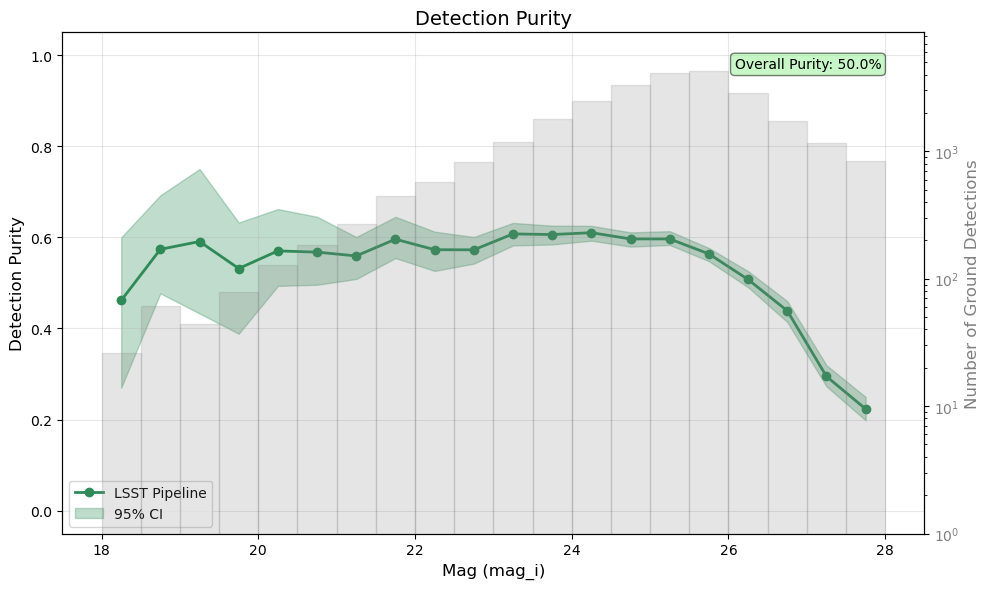

In [14]:
mag_bins = np.arange(18, 28.5, 0.5)
results = run_purity_analysis(
    ground_cat, 
    space_cat,
    ground_coord_ra='coord_ra',
    ground_coord_dec='coord_dec',
    mag_bins=mag_bins,  # magnitude bins
    n_bootstrap=100,
    confidence_level=0.95         # 95% confidence intervals
)

# Access results
print(f"\nFinal overall completeness: {results['overall_purity']:.1%}")
if results['overall_ci'] is not None:
    print(f"95% CI: ({results['overall_ci'][0]:.1%}, {results['overall_ci'][1]:.1%})")

# Creating DP1 Cutouts for DeepDISC

In [19]:
patch_id = 25
patch_cutout = f'full_p{patch_id}.npy'
patch_cat = f'full_p{patch_id}.json'
lsst_iband_img = np.load(patch_cutout)[3,:, :]
patch_cat = pd.read_json(patch_cat, orient='records')

In [8]:
patch_cat['mag_i'].describe()

count    3712.000000
mean       25.449332
std         3.175142
min        16.934532
25%        24.363937
50%        25.339314
75%        26.182948
max        83.502563
Name: mag_i, dtype: float64

Text(0.5, 1.0, 'Patch 25 - 3772 objects')

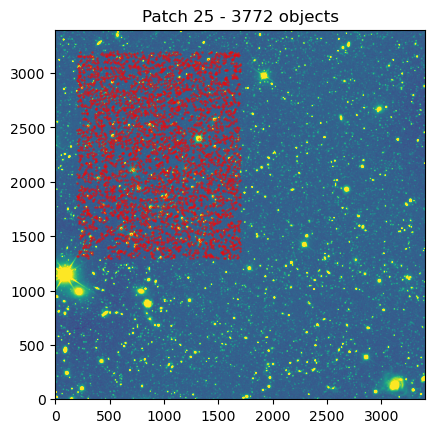

In [20]:
# fig, ax = plt.subplots(1)
plt.imshow(lsst_iband_img, norm=asinh_norm(lsst_iband_img, a=0.1), origin='lower', cmap='viridis')
plt.scatter(patch_cat['cutout_x'], patch_cat['cutout_y'], marker='x', color='red', alpha=0.5, s=1, label='DP1 Dets')
plt.title(f'Patch {patch_id} - {len(patch_cat)} objects')
# plt.xlim(200, 3200)
# plt.ylim(200, 3200)

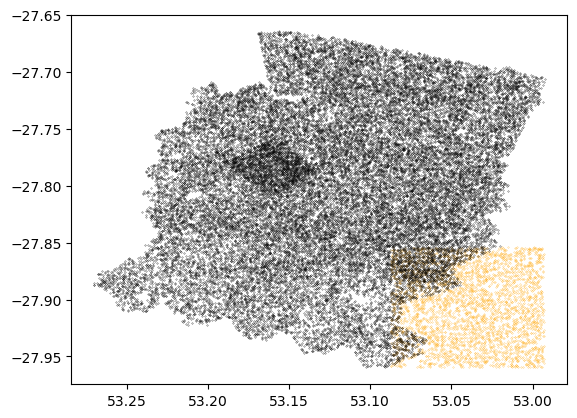

In [21]:
plt.scatter(patch_cat['coord_ra'], patch_cat['coord_dec'], s=0.03, c=['orange'], label='DP1 Detections')
plt.scatter(space_cat['RA'], space_cat['DEC'], s=0.05, label='HST Detections', c=['black'])
plt.gca().invert_xaxis()

In [105]:
lsst_iband_img.shape

(3400, 3400)

In [114]:
patch_cat['cutout_x'].min(), patch_cat['cutout_y'].max()
# 3000, 3000

(291.5786738064, 3199.375937116)

In [22]:
def create_cutouts(patch_id, w):
    print(f"---------- Processing Patch {patch_id} ------------")
    patch_cutout = f'full_p{patch_id}.npy'
    patch_cat = f'full_p{patch_id}.json'
    full_img_data = np.load(patch_cutout)
    
    cutout_size = 128
    coadd_size = full_img_data.shape[1:]
    overlap_pixels = 200
    
    df_cat = pd.read_json(patch_cat, orient='records')
    print(f"Loaded catalog with {len(df_cat)} objects")
    # pixel coordinates from catalog
    xpix = df_cat['cutout_x'].values
    ypix = df_cat['cutout_y'].values

    # keep only catalog points that fall on the patch image
    H, W = coadd_size[0], coadd_size[1]
    on_patch = (xpix >= 0) & (xpix < W) & (ypix >= 0) & (ypix < H)
    xpix_valid = xpix[on_patch]
    ypix_valid = ypix[on_patch]
    print(f"Found {len(xpix_valid)} catalog objects on patch")
    
    # only use the core region avoiding 500px overlap on each edge
    usable_width = coadd_size[1] - 2 * overlap_pixels  # 3000
    usable_height = coadd_size[0] - 2 * overlap_pixels  # 3000
    start_x, start_y = overlap_pixels, overlap_pixels  # 200, 200
    
    nx_cutouts = usable_width // cutout_size
    ny_cutouts = usable_height // cutout_size
        
    # calc spacing to distribute cutouts evenly
    if nx_cutouts > 1:
        x_spacing = (usable_width - cutout_size) // (nx_cutouts - 1)
    else:
        x_spacing = 0

    if ny_cutouts > 1:
        y_spacing = (usable_height - cutout_size) // (ny_cutouts - 1)
    else:
        y_spacing = 0
    
#     print(f"Creating cutouts for {ra_dec[0]}_{ra_dec[1]}...")
    print(f"Image size: {coadd_size[1]}x{coadd_size[0]}")
    print(f"Usable region: {usable_width}x{usable_height} (starting at {start_x},{start_y})")
    print(f"Cutouts: {nx_cutouts}x{ny_cutouts} = {nx_cutouts * ny_cutouts} total")
    print(f"Spacing: x={x_spacing}, y={y_spacing}")
    
    cutout_info_list = []
    viable_count = 0
    
    counter = 0
    for i in range(ny_cutouts):
        for j in range(nx_cutouts):
           # cutout center pos
            if ny_cutouts == 1:
                y_center = start_y + cutout_size // 2
            else:
                y_center = start_y + cutout_size // 2 + i * y_spacing
            
            if nx_cutouts == 1:
                x_center = start_x + cutout_size // 2
            else:
                x_center = start_x + cutout_size // 2 + j * x_spacing

            x0 = x_center - cutout_size // 2
            y0 = y_center - cutout_size // 2
            x1 = x0 + cutout_size
            y1 = y0 + cutout_size
            
            if len(xpix_valid) > 0:
                inside = (xpix_valid >= x0) & (xpix_valid < x1) & (ypix_valid >= y0) & (ypix_valid < y1)
                n_objs = int(inside.sum())
                is_viable = n_objs >= 1 # at least one obj in each cutout to make it viable
                if is_viable:
                    viable_count += 1
            else:
                n_objs = 0
                is_viable = False
            
            full_cutout_path = f'p{patch_id}/full_c{counter}.npy'
            if not os.path.exists(full_cutout_path):
                raw_cutout_u = Cutout2D(full_img_data[0, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                raw_cutout_g = Cutout2D(full_img_data[1, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                raw_cutout_r = Cutout2D(full_img_data[2, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                raw_cutout_i = Cutout2D(full_img_data[3, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                raw_cutout_z = Cutout2D(full_img_data[4, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                raw_cutout_y = Cutout2D(full_img_data[5, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)

                full_raw_cutout = np.stack((
                    raw_cutout_u.data,
                    raw_cutout_g.data,
                    raw_cutout_r.data,
                    raw_cutout_i.data,
                    raw_cutout_z.data,
                    raw_cutout_y.data
                ))

                np.save(full_cutout_path, full_raw_cutout)
                wcs_string = raw_cutout_i.wcs.to_header_string()
            else:
                # If file exists, we still need to create a cutout to get WCS info
                raw_cutout_i = Cutout2D(full_img_data[3, :, :], position=(x_center, y_center), 
                                        size=cutout_size, wcs=w, mode='partial', fill_value=0)
                wcs_string = raw_cutout_i.wcs.to_header_string()
#             f'./lsst_data/{folder}/test.json'
            cutout_info = {
                "file_name": './dp1/' + full_cutout_path,
                "height": cutout_size,
                "width": cutout_size,
                "patch": patch_id,
                "wcs": wcs_string,
                "viable": is_viable,
                "n_catalog_objects": n_objs
            }
            cutout_info_list.append(cutout_info)
            
            # debug info for first few cutouts
            if counter < 3:
                print(f"  Cutout {counter}: center=({x_center}, {y_center}), "
                      f"bbox=({x_center-cutout_size//2}, {y_center-cutout_size//2}, "
                      f"{x_center+cutout_size//2}, {y_center+cutout_size//2})")
            
            counter += 1
    
    print(f"Created {counter} cutouts")
    return cutout_info_list

In [23]:
with open('wcs_dp1.json', 'r') as f:
    all_wcs = json.load(f)

In [24]:
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
patch_ids = [24, 25, 34, 35, 44, 45]
all_cutouts_info = []

for patch_id in patch_ids:
    wcs = WCS(all_wcs[f'{patch_id}'])
    cutout_info_list = create_cutouts(patch_id, wcs)
    all_cutouts_info.extend(cutout_info_list)

with open('test.json', 'w') as f:
    json.dump(all_cutouts_info, f, indent=2)

---------- Processing Patch 24 ------------
Loaded catalog with 7135 objects
Found 7135 catalog objects on patch
Image size: 3400x3400
Usable region: 3000x3000 (starting at 200,200)
Cutouts: 23x23 = 529 total
Spacing: x=130, y=130
  Cutout 0: center=(264, 264), bbox=(200, 200, 328, 328)
  Cutout 1: center=(394, 264), bbox=(330, 200, 458, 328)
  Cutout 2: center=(524, 264), bbox=(460, 200, 588, 328)
Created 529 cutouts
---------- Processing Patch 25 ------------
Loaded catalog with 3772 objects
Found 3772 catalog objects on patch
Image size: 3400x3400
Usable region: 3000x3000 (starting at 200,200)
Cutouts: 23x23 = 529 total
Spacing: x=130, y=130
  Cutout 0: center=(264, 264), bbox=(200, 200, 328, 328)
  Cutout 1: center=(394, 264), bbox=(330, 200, 458, 328)
  Cutout 2: center=(524, 264), bbox=(460, 200, 588, 328)
Created 529 cutouts
---------- Processing Patch 34 ------------
Loaded catalog with 11063 objects
Found 11063 catalog objects on patch
Image size: 3400x3400
Usable region: 3000

In [25]:
total_cutouts = len(all_cutouts_info)
viable_cutouts = sum(1 for cutout in all_cutouts_info if cutout['viable'])
print(f"Summary:")
print(f"Total cutouts: {total_cutouts}")
print(f"Viable cutouts: {viable_cutouts}")
print(f"Viable percentage: {viable_cutouts/total_cutouts*100:.1f}%")
print(f"Saved cutout information to test.json")

Summary:
Total cutouts: 3174
Viable cutouts: 1465
Viable percentage: 46.2%
Saved cutout information to test.json


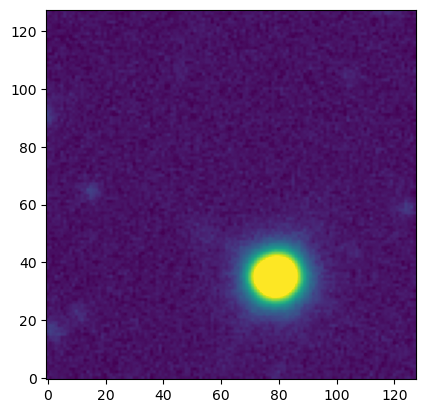

In [26]:
patch_id = 45
cutout_num = 200
patch_cutout = f'p{patch_id}/full_c{cutout_num}.npy'
# patch_cat = f'full_p{patch_id}.json'
lsst_iband_img = np.load(patch_cutout)[3,:, :]
plt.imshow(lsst_iband_img, norm=asinh_norm(lsst_iband_img, a=0.1), origin='lower', cmap='viridis')

In [10]:
import os, json
import numpy as np
import pandas as pd
from astropy.wcs import WCS

CUTOUT_SIZE = 128
OVERLAP = 200  # same as your overlap_pixels

# --- helpers ---------------------------------------------------------------
sum_df = 0
def _cutout_grid_boxes(coadd_h, coadd_w, cutout_size=CUTOUT_SIZE, overlap=OVERLAP):
    # Build the identical grid you used for cutout creation
    start_x = overlap
    start_y = overlap
    usable_w = coadd_w - 2 * overlap
    usable_h = coadd_h - 2 * overlap

    nx = usable_w // cutout_size
    ny = usable_h // cutout_size

    x_spacing = (usable_w - cutout_size) // (nx - 1) if nx > 1 else 0
    y_spacing = (usable_h - cutout_size) // (ny - 1) if ny > 1 else 0

    boxes = []   # (idx, x0, y0, x1, y1)
    idx = 0
    for i in range(ny):
        y0 = start_y + i * y_spacing
        y1 = y0 + cutout_size
        for j in range(nx):
            x0 = start_x + j * x_spacing
            x1 = x0 + cutout_size
            boxes.append((idx, x0, y0, x1, y1))
            idx += 1

    meta = dict(nx=nx, ny=ny, x_spacing=x_spacing, y_spacing=y_spacing,
                start=(start_x, start_y), cutout_size=cutout_size)
    return boxes, meta

def viable_cutouts_for_patch(patch_id, wcs, catalog_json_path,
                             full_npy_path=None,
                             coadd_shape=None,  # (H, W); supply if you don't want to open the npy
                             min_objects_per_cutout=1,
                             require_full_within_catalog_rect=False,
                             shrink_border=0):
    """
    Returns:
      viable_ids: list of cutout indices (match full_c{idx}.npy)
      counts: dict {idx: n_catalog_objects_in_cutout}
      info: metadata dict
    """
    global sum_df
    # Get patch size
    if coadd_shape is None:
        if full_npy_path is None:
            full_npy_path = f'full_p{patch_id}.npy'
        arr = np.load(full_npy_path, mmap_mode='r')   # shape: (bands, H, W)
        H, W = arr.shape[1], arr.shape[2]
    else:
        H, W = coadd_shape

    boxes, meta = _cutout_grid_boxes(H, W)

    # Load catalog
    df = pd.read_json(catalog_json_path, orient='records')
    print(f"Len of df {len(df)}")
    sum_df += len(df)
    xpix, ypix, used_cols = df['cutout_x'].values, df['cutout_y'].values, ('cutout_x', 'cutout_y')

    # Keep only catalog points that fall on the patch image
    on_patch = (xpix >= 0) & (xpix < W) & (ypix >= 0) & (ypix < H)
    xpix = xpix[on_patch]
    ypix = ypix[on_patch]

    # Optional: build catalog coverage rectangle (in pixel coords)
    if require_full_within_catalog_rect and xpix.size:
        xmin, xmax = float(xpix.min()), float(xpix.max())
        ymin, ymax = float(ypix.min()), float(ypix.max())
        # shrink a bit to be conservative if desired
        xmin += shrink_border
        ymin += shrink_border
        xmax -= shrink_border
        ymax -= shrink_border
    else:
        xmin = ymin = -np.inf
        xmax = ymax = +np.inf

    # For each cutout, count points; keep if count >= min_objects
    viable_ids = []
    counts = {}
    # Vectorized point-in-rect check per cutout (529 cutouts × ~10^3 points is cheap)
    for idx, x0, y0, x1, y1 in boxes:
        if require_full_within_catalog_rect:
            # Skip cutouts not fully inside catalog rectangle
            if not (x0 >= xmin and x1 <= xmax and y0 >= ymin and y1 <= ymax):
                continue

        inside = (xpix >= x0) & (xpix < x1) & (ypix >= y0) & (ypix < y1)
        n = int(inside.sum())
        if n >= min_objects_per_cutout:
            viable_ids.append(idx)
            counts[idx] = n

    info = dict(patch_id=patch_id, H=H, W=W, used_catalog_cols=used_cols, **meta)
    return viable_ids, counts, info

In [11]:
with open('wcs_dp1.json', 'r') as f:
    all_wcs = json.load(f)

patch_ids = [24, 25, 34, 35, 44, 45]

viable_by_patch = {}
for pid in patch_ids:
    w = WCS(all_wcs[str(pid)])
    cat_path = f'full_p{pid}.json'   # your catalog
    full_path = f'full_p{pid}.npy'   # to get shape via mmap

    # Option A (most common): keep cutouts that contain ≥1 catalog object
    valid_ids, counts, info = viable_cutouts_for_patch(
        pid, w, cat_path, full_npy_path=full_path,
        min_objects_per_cutout=1,
        require_full_within_catalog_rect=False
    )

    # Option B (stricter): keep cutouts fully inside catalog coverage rectangle
    # valid_ids, counts, info = viable_cutouts_for_patch(
    #     pid, w, cat_path, full_npy_path=full_path,
    #     min_objects_per_cutout=0,
    #     require_full_within_catalog_rect=True,
    #     shrink_border=0  # set to 64 if you want a safety margin of half a cutout
    # )

    viable_by_patch[str(pid)] = dict(valid_cutout_ids=valid_ids,
                                     counts_per_cutout=counts,
                                     grid_info=info)

# Quick printout
for pid in patch_ids:
    n = len(viable_by_patch[str(pid)]['valid_cutout_ids'])
    print(f"Patch {pid}: {n} viable cutouts")
    
# Save list for later use
# with open('viable_cutouts.json', 'w') as f:
#     json.dump(viable_by_patch, f, indent=2, sort_keys=True)


Len of df 7135
Len of df 3772
Len of df 11063
Len of df 5969
Len of df 1313
Len of df 748
Patch 24: 345 viable cutouts
Patch 25: 180 viable cutouts
Patch 34: 529 viable cutouts
Patch 35: 276 viable cutouts
Patch 44: 88 viable cutouts
Patch 45: 47 viable cutouts


In [12]:
print(sum_df)

30000


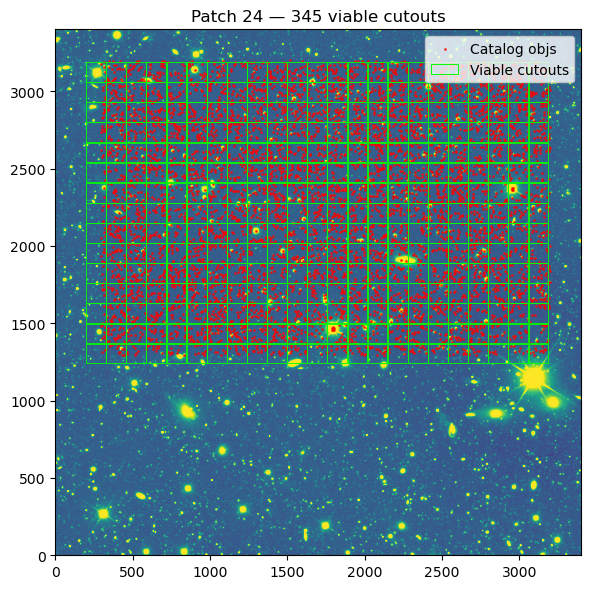

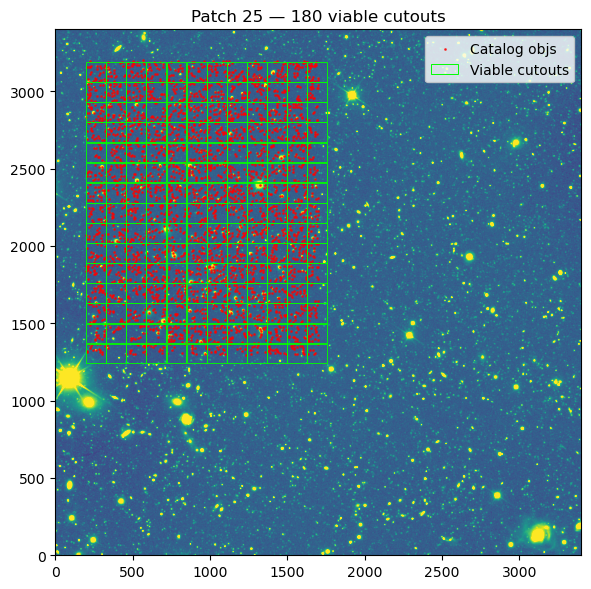

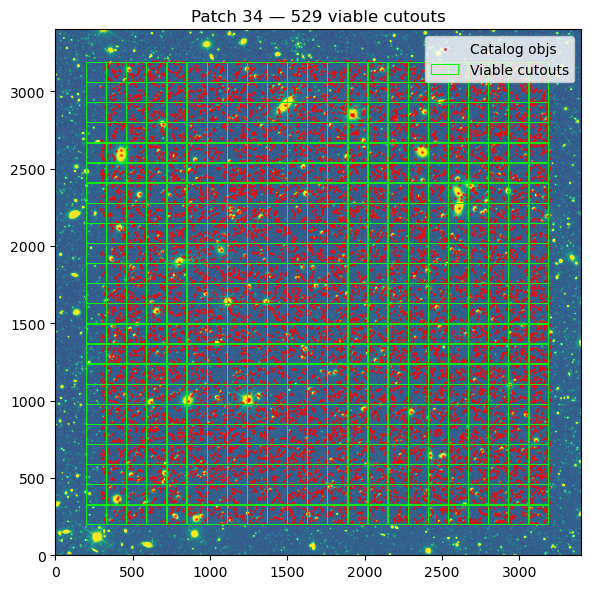

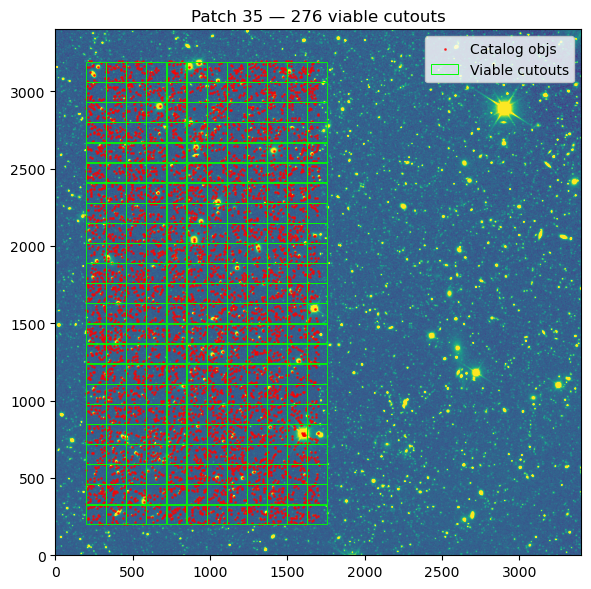

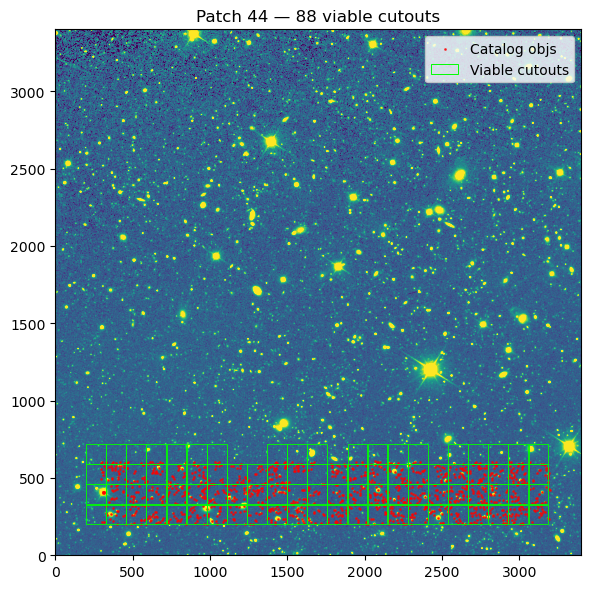

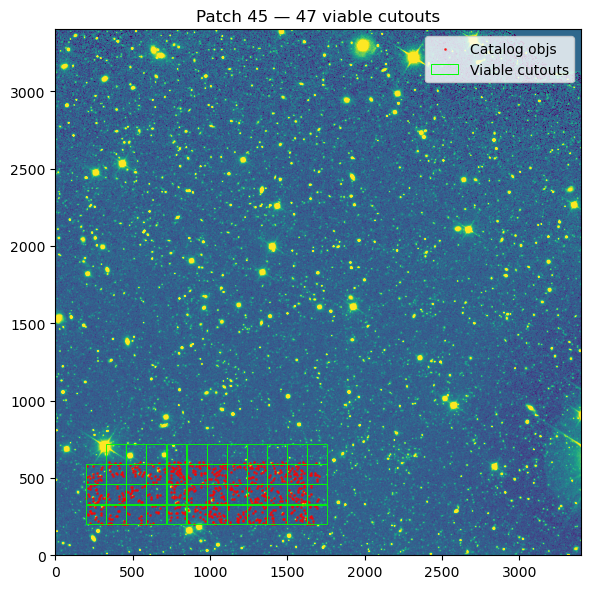

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_viable_overlay(patch_id, viable_by_patch,
                        full_npy_path=None,
                        catalog_json_path=None,
                        band_index=3,              # 0:u, 1:g, 2:r, 3:i, 4:z, 5:y
                        show_invalid=False,        # set True to also draw the non-viable cutouts
                        rect_lw=0.7,
                        figsize=(6, 6),
                        cmap='viridis'):
    """
    Visualize a patch with catalog points and rectangles for viable cutouts.
    """
    if full_npy_path is None:
        full_npy_path = f'full_p{patch_id}.npy'
    if catalog_json_path is None:
        catalog_json_path = f'full_p{patch_id}.json'

    # Load image and choose a band for background
    arr = np.load(full_npy_path, mmap_mode='r')  # (6, H, W)
    H, W = arr.shape[1], arr.shape[2]
    img = arr[band_index].astype(float)

    # Simple stretch for display
    lo, hi = np.nanpercentile(img, [0.5, 99.5])
    lo = max(lo, np.min(img))
    hi = max(hi, lo + 1e-6)

    # Load catalog points (already in full-image pixel coords)
    with open(catalog_json_path, 'r') as f:
        cat = json.load(f)
    cdf = pd.DataFrame(cat)
    xpix = cdf['cutout_x'].values
    ypix = cdf['cutout_y'].values
    on_patch = (xpix >= 0) & (xpix < W) & (ypix >= 0) & (ypix < H)
    xpix, ypix = xpix[on_patch], ypix[on_patch]

    # Build the same cutout boxes
    boxes, meta = _cutout_grid_boxes(H, W)  # uses your CUTOUT_SIZE and OVERLAP
    valid = set(viable_by_patch[str(patch_id)]['valid_cutout_ids'])

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, norm=asinh_norm(lsst_iband_img, a=0.1), origin='lower', cmap=cmap)
    ax.scatter(xpix, ypix, s=1, c='red', alpha=0.7, label='Catalog objs')

    # Draw rectangles
    for idx, x0, y0, x1, y1 in boxes:
        is_valid = idx in valid
        if not is_valid and not show_invalid:
            continue
        ec = 'lime' if is_valid else 'gray'
        ax.add_patch(Rectangle((x0, y0),
                               width=x1 - x0,
                               height=y1 - y0,
                               fill=False, lw=rect_lw, ec=ec, alpha=0.9))

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal')
    ax.set_title(f'Patch {patch_id} — {len(valid)} viable cutouts')
    handles, labels = ax.get_legend_handles_labels()
    if show_invalid:
        handles += [Rectangle((0,0),1,1, fill=False, ec='gray', lw=rect_lw)]
        labels += ['Non-viable cutouts']
    handles += [Rectangle((0,0),1,1, fill=False, ec='lime', lw=rect_lw)]
    labels += ['Viable cutouts']
    ax.legend(handles, labels, loc='upper right', frameon=True)
    plt.tight_layout()

# Example: plot each patch you listed
for pid in [24, 25, 34, 35, 44, 45]:
    plot_viable_overlay(pid, viable_by_patch,
                        full_npy_path=f'full_p{pid}.npy',
                        catalog_json_path=f'full_p{pid}.json',
                        band_index=3,          # i-band background
                        show_invalid=False,    # set True if you want to also see non-viable cutouts
                        figsize=(6, 6))

In [63]:
for patch_id, df_patch in ground_cat.groupby('patch'):
    print(f"Patch {patch_id}: {len(df_patch)}")
    filepath = f'full_p{patch_id}.json'
    df_patch.to_json(filepath, orient='records')

Patch 24: 7135
Patch 25: 3772
Patch 34: 11063
Patch 35: 5969
Patch 44: 1313
Patch 45: 748


In [ ]:
all_wcs = {}
for i, patch_id in enumerate(patch_ids):
    print(f"Loading data for Patch {patch_id}...")
    exp = coadd_dict[bands[3]][patch_id]
    full_cat = pd.read_json('/global/homes/y/yaswante/lsst_dets_hst.json', orient='records')
    final_cat, wcs_header = get_cat(patch_id, exp, full_cat, 30)
    all_wcs[patch_id] = wcs_header

    print(f"Saving {len(final_cat)} objects for Patch {patch_id}")
    final_cat.to_json(f'/global/homes/y/yaswante/full_p{patch_id}.json', orient='records')

with open('/global/homes/y/yaswante/wcs_dp1.json', 'w') as f:
    json.dump(all_wcs, f, indent=4)

# Creating DeepDISC Metadata for each cutout

In [3]:
import numpy as np
import pandas as pd
import galsim
import cv2
import multiprocessing as mp
import argparse
import warnings

from astropy.table import Table
from astropy.stats import gaussian_fwhm_to_sigma
from scipy.special import gammainc, gammaincinv
from scipy.optimize import root_scalar

In [4]:
def b_n(n):
    """Returns the b(n) parameter for a given Sersic index n."""
    return gammaincinv(2.0 * n, 0.5)

def cumulative_sersic(r_frac, n):
    """Returns the cumulative flux fraction at r/r_eff = r_frac."""
    b = b_n(n)
    return gammainc(2.0 * n, b * r_frac ** (1.0 / n))

def flux_ratio_error(n, r20_r50):
    """Function to be zeroed to find the correct n."""
    # Calculates the flux fraction at the r20 radius, assuming r_eff=r50
    f20 = cumulative_sersic(r20_r50, n)
    # We want to find n where the flux fraction is 0.2
    return f20 - 0.2

def estimate_sersic_index(r20, r50):
    """
    Estimates the Sersic index n given r20 and r50 radii.
    NOTE: r20 and r50 must not be zero and r20 < r50.
    """
    if r50 <= 0 or r20 <= 0 or r20 >= r50:
        return np.nan # Invalid input
        
    r_ratio = r20 / r50
    try:
        # Bracket defines the range of n to search (0.1 to 10 is very safe)
        result = root_scalar(flux_ratio_error, args=(r_ratio,), bracket=[0.1, 10.0], method='brentq')
        return result.root if result.converged else np.nan
    except ValueError:
        # Occurs if the solution is not in the bracket
        return np.nan

In [ ]:
def make_star(entry):
    """Builds a star model for HST data."""
    flux = entry['FLUX_BEST_F160W']
    # Model the star as a tiny Gaussian (a proxy for a delta function)
    star = galsim.Gaussian(fwhm=1.0e-8, flux=flux)
    return star

def make_galaxy_hst(entry, survey, n_estimate):
    """Builds a single-component Sersic galaxy model for HST data."""
    # Use F160W as the primary detection band for morphology
    pixel_scale = survey.pixel_scale 
    
    # --- Parameter gathering ---
    flux = entry['FLUX_BEST_F160W']
    # FLUX_RADIUS is in pixels, convert to arcseconds for galsim
    half_light_radius = entry['FLUX_RADIUS_2_F160W'] * pixel_scale
    
    # --- Create the Sersic profile ---
    galaxy = galsim.Sersic(n=n_estimate, half_light_radius=half_light_radius, flux=flux)

    # --- Apply shape ---
    q = entry['B_IMAGE'] / entry['A_IMAGE']  # Axis ratio
    beta = entry['THETA_IMAGE'] * galsim.degrees
    galaxy = galaxy.shear(q=q, beta=beta)
    
    return galaxy

# =================================================================
# 4. DISPATCHER AND MAIN PROCESSING LOGIC
# =================================================================
def convolve_source_hst(entry, survey):
    """
    Determines object type, creates the galsim model, and convolves with the PSF.
    """
    psf = survey.psf
    
    # --- Dispatch based on CLASS_STAR ---
    # Use a threshold to classify objects
    if entry['CLASS_STAR'] > 0.9:
        obj = make_star_hst(entry, survey)
    elif entry['CLASS_STAR'] < 0.1:
        # --- Estimate the Sersic Index 'n' ---
        # IMPORTANT: Verify that FLUX_RADIUS_1 in your catalog corresponds to 20% flux.
        # If it's a different percentage, the helper functions must be adjusted.
        r20 = entry['FLUX_RADIUS_1_F160W']
        r50 = entry['FLUX_RADIUS_2_F160W']
        
        n_estimate = estimate_sersic_index(r20, r50)
        
        if np.isnan(n_estimate):
            # If estimation fails, fall back to a default (e.g., n=1 for disk)
            n_estimate = 1.0

        obj = make_galaxy_hst(entry, survey, n_estimate)
    else:
        # Object is ambiguous, skip it
        return None, None

    # Convolve the final object with the PSF
    final_obj = galsim.Convolve(obj, psf)
    return final_obj, psf

def process_object_hst(entry, survey, se_kernel, snr_lvl=5):
    """
    Processes a single object from the CANDELS catalog to generate an annotation.
    """
    # --- Create the simulated, noiseless image of the object ---
    conv_obj, psf = convolve_source_hst(entry, survey)
    
    if conv_obj is None:
        # This means the object was ambiguous or failed creation
        return 'rejected', {'obj_id': entry['ID'], 'reason': 'ambiguous_class_star'}

    # --- Generate segmentation mask and annotations ---
    # This logic is largely the same as your original script.
    # It takes the `conv_obj`, draws it, creates a mask based on SNR,
    # checks for rejection conditions (e.g., empty mask, too small),
    # and calculates the bbox and segmentation polygons.
    
    # Placeholder for the existing logic:
    # try:
    #     image = conv_obj.drawImage(...)
    #     mask = create_mask_from_snr_threshold(image, ...)
    #     if is_rejected(mask):
    #         return 'rejected', {'obj_id': entry['ID'], 'reason': 'empty_or_small_mask'}
    #     
    #     bbox = get_bbox(mask)
    #     segmentation = get_contours(mask)
    #
    # except Exception as e:
    #     return 'rejected', {'obj_id': entry['ID'], 'reason': f'galsim_failure: {e}'}

    # --- If successful, package the final annotation ---
    # Example obj_md = {
    #     'obj_id': entry['ID'],
    #     'category_id': 0 if entry['CLASS_STAR'] < 0.1 else 1,
    #     'bbox': bbox,
    #     'segmentation': segmentation,
    #     'ra': entry['RA'],
    #     'dec': entry['DEC'],
    #      ... other metadata ...
    # }
    # return 'success', obj_md
    
    # For this template, we'll return a placeholder success
    return 'success', {'obj_id': entry['ID']}


# =================================================================
# 5. MAIN SCRIPT EXECUTION
# =================================================================
def main(args):
    print(f"Loading CANDELS catalog from: {args.input_fits}")
    catalog = Table.read(args.input_fits).to_pandas()
    
    # --- Define the HST Survey Properties ---
    hst_pixel_scale = 0.06  # arcsec/pixel for WFC3/IR
    # Create a realistic PSF model for HST F160W
    hst_psf = galsim.Moffat(beta=1.5, fwhm=0.15) # Example PSF
    hst_survey = galsim.SurveyProperties(psf=hst_psf, pixel_scale=hst_pixel_scale)
    
    # --- Prepare for processing ---
    # This kernel is used to dilate the segmentation mask slightly
    sig = gaussian_fwhm_to_sigma * hst_psf.calculateFWHM() / hst_pixel_scale
    se_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(2 * sig), int(2 * sig)))

    annotations = []
    rejected_objs = []
    
    # NOTE: This is a serial loop for clarity. You can adapt this
    # to use multiprocessing.Pool as in your original script.
    print(f"Processing {len(catalog)} objects...")
    for index, entry in catalog.iterrows():
        status, result = process_object_hst(entry, hst_survey, se_kernel)
        if status == 'success':
            annotations.append(result)
        else:
            rejected_objs.append(result)

    print(f"Finished. Generated {len(annotations)} successful annotations.")
    print(f"Logged {len(rejected_objs)} rejected objects.")

    # --- Save the results ---
    pd.DataFrame(annotations).to_json(args.output_ann_path, orient='records', indent=4)
    pd.DataFrame(rejected_objs).to_json(args.output_rej_path, orient='records', indent=4)
    print(f"Results saved to {args.output_ann_path} and {args.output_rej_path}")


if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    parser = argparse.ArgumentParser(description="Generate annotations from a CANDELS catalog.")
    parser.add_argument("input_fits", type=str, help="Path to the input CANDELS FITS catalog.")
    parser.add_argument("output_ann_path", type=str, help="Path to save the output successful annotations JSON file.")
    parser.add_argument("output_rej_path", type=str, help="Path to save the output rejected objects JSON file.")
    
    args = parser.parse_args()
    main(args)

In [ ]:
# --- Configuration ---
root_dir = './lsst_data/'
lsst_dir = f'{root_dir}truth/'

cutouts_per_tile = 1 # we shld prob just dynamically calculate this by looking through the truth folders
seed = 8312
rng = np.random.RandomState(seed)
grng = galsim.BaseDeviate(rng.randint(0, 2**30))

def e1e2_to_ephi(e1,e2):
    pa = np.arctan(e2/e1)
    return pa

def dcut_reformat(cat):
    L0 = 3.0128e28
    for band in ['u', 'g', 'r', 'i', 'z', 'y']:
        cat[f'{band}_ab'] = cat[f'mag_true_{band}']
        total_flux = L0 * 10**(-0.4*cat[f'mag_true_{band}'])
        bulge_to_total_ratio = cat[f'bulge_to_total_ratio_{band}']

        cat[f'fluxnorm_bulge_{band}'] = total_flux * bulge_to_total_ratio
        cat[f'fluxnorm_disk_{band}'] = total_flux * (1-bulge_to_total_ratio)
        cat[f'fluxnorm_agn_{band}'] = np.zeros(total_flux.shape)

    cat['a_b'] = cat['size_bulge_true']
    cat['b_b'] = cat['size_minor_bulge_true']

    cat['a_d'] = cat['size_disk_true']
    cat['b_d'] = cat['size_minor_disk_true']
    # pos angle
    cat['pa_bulge'] = e1e2_to_ephi(cat['ellipticity_1_bulge_true'],cat['ellipticity_2_bulge_true']) * 180.0/np.pi

    cat['pa_disk'] = e1e2_to_ephi(cat['ellipticity_1_disk_true'],cat['ellipticity_2_disk_true']) * 180.0/np.pi
    
    cat['pa_tot'] = e1e2_to_ephi(cat['ellipticity_1_true'],cat['ellipticity_2_true']) * 180.0/np.pi

    cat['g1'] = cat['shear_1']
    cat['g2'] = cat['shear_2']
    
    return cat

class SourceNotVisible(Exception):
    """Custom exception for objects with zero flux"""
    pass

def get_star_gsparams(mag, flux, noise):
    """
    Gets appropriate GSParams for a star given flux and noise

    Parameters
    ----------
    mag : float
        mag of star
    flux : float
        flux of star in electrons
    noise : float
        Mean sky background level in electrons. In background-limited
        scenarios, this value serves as a proxy for the noise variance
        (i.e., noise_rms^2) and is used to set Fourier-space accuracy parameters

    Returns
    -------
    galsim.GSParams or None
        An appropriate GSParams object for the star, or None if the star is
        not bright enough to require special handling
    bool
        A boolean flag, `isbright`, which is True if mag < 18
    """
    do_thresh = do_acc = False
    if mag < 18:
        do_thresh = True
    if mag < 15:
        do_acc = True

    if do_thresh or do_acc:
        isbright = True

        kw = {}
        if do_thresh:

            # this is designed to quantize the folding_threshold values,
            # so that there are fewer objects in the GalSim C++ cache.
            # With continuous values of folding_threshold, there would be
            # a moderately largish overhead for each object.

            folding_threshold = noise/flux
            folding_threshold = np.exp(
                np.floor(np.log(folding_threshold))
            )
            kw['folding_threshold'] = min(folding_threshold, 0.005)

        if do_acc:
            kw['kvalue_accuracy'] = 1.0e-8
            kw['maxk_threshold'] = 1.0e-5

        gsparams = galsim.GSParams(**kw)
    else:
        gsparams = None
        isbright = False

    return gsparams, isbright

def make_star(entry, filt, noise):
    """
    Builds a star model as a GalSim GSObject.

    The star is modeled as a very small Gaussian to approximate a delta
    function, which can then be convolved with a PSF. Flux is calculated
    directly from the magnitude with a zeropoint of 27.

    Parameters
    ----------
    entry : dict-like
        A catalog entry containing properties of the object, including
        the magnitude in the specified filter (e.g., `entry['mag_g']`).
    filt : galsim.Bandpass
        The filter bandpass object.
    noise : float
        The empirically measured background noise (RMS) in electrons

    Returns
    -------
    galsim.GSObject
        The star model as a GalSim object.
    galsim.GSParams or None
        The GSParams used for the star model.
    float
        The calculated flux of the star in electrons.
    """
    # https://pipelines.lsst.io/v/DM-22499/cpp-api/file/_photo_calib_8h.html
    # mag = -2.5*np.log10(entry[f'flux_{filt.name}']*1e-9/(1e23*10**(48.6/-2.5)))
    mag = entry[f'mag_{filt.name}']
    # For zeropoint mag:
    # https://community.lsst.org/t/dp0-zeropoints-adding-poisson-noise/8230
    # https://www.aanda.org/articles/aa/pdf/2025/03/aa52119-24.pdf (Pg. 4)
    delta_m = mag - 27 # mag 27 is zeropoint for LSST coadds
    flux = 10 ** (-delta_m / 2.5)
    gsparams, isbright = get_star_gsparams(mag, flux, noise)
    star = galsim.Gaussian(
        fwhm=1.0e-4,
        flux=flux,
        gsparams=gsparams,
    )
    return star, gsparams, flux

def make_galaxy(entry, filt, no_disk=False, no_bulge=False, no_agn=True):
    """
    Builds a galaxy model as a composite GalSim GSObject.

    The galaxy can be composed of a disk (Exponential), a bulge
    (DeVaucouleurs), and an AGN (point source). The flux of each component
    is scaled based on the total magnitude, which is converted to flux
    with a zeropoint of 27.

    Parameters
    ----------
    entry : dict-like
        Catalog entry with galaxy properties (flux normalizations, sizes,
        position angle, etc.).
    filt : galsim.Bandpass
        The filter bandpass object.
    no_disk : bool, optional
        If True, the disk component will not be added. Defaults to False.
    no_bulge : bool, optional
        If True, the bulge component will not be added. Defaults to False.
    no_agn : bool, optional
        If True, the AGN component will not be added. Defaults to True.

    Returns
    -------
    galsim.GSObject
        The composite galaxy profile as a single GalSim object.
    """
    components = []
    mag = entry[filt.name + "_ab"]
    # https://community.lsst.org/t/dp0-zeropoints-adding-poisson-noise/8230
    # https://www.aanda.org/articles/aa/pdf/2025/03/aa52119-24.pdf (Pg. 4)
    delta_m = mag - 27
    total_flux = 10 ** (-delta_m / 2.5)
    # Calculate the flux of each component in detected electrons.
    total_fluxnorm = entry["fluxnorm_disk_"+filt.name] + entry["fluxnorm_bulge_"+filt.name] + entry["fluxnorm_agn_"+filt.name]
    disk_flux = 0.0 if no_disk else entry["fluxnorm_disk_"+filt.name] / total_fluxnorm * total_flux
    bulge_flux = 0.0 if no_bulge else entry["fluxnorm_bulge_"+filt.name] / total_fluxnorm * total_flux
    agn_flux = 0.0 if no_agn else entry["fluxnorm_agn_"+filt.name] / total_fluxnorm * total_flux

    if disk_flux + bulge_flux + agn_flux == 0:
        raise SourceNotVisible
    
    pa = np.pi*entry['position_angle_true_dc2']/180
    if disk_flux > 0:
        a_d, b_d = entry["a_d"], entry["b_d"]
        disk_hlr_arcsecs=a_d
        
        disk_q = b_d/a_d
        
        epsilon_disk = (1 - disk_q) / (1 + disk_q)
        
        e1_disk = epsilon_disk * np.cos(2 * pa)
        e2_disk = epsilon_disk * np.sin(2 * pa)

        disk = galsim.Exponential(flux=disk_flux, half_light_radius=disk_hlr_arcsecs).shear(
            e1=-e1_disk, e2=e2_disk
        )
        
        components.append(disk)
        
    if bulge_flux > 0:
        a_b, b_b = entry["a_b"], entry["b_b"]
        bulge_hlr_arcsecs = np.sqrt(a_b * b_b)
        
        bulge_q = b_b/a_b
        epsilon_bulge = (1 - bulge_q) / (1 + bulge_q)
        
        e1_bulge = epsilon_bulge * np.cos(2 * pa)
        e2_bulge = epsilon_bulge * np.sin(2 * pa)
        
        bulge = galsim.DeVaucouleurs(flux=bulge_flux, half_light_radius=bulge_hlr_arcsecs).shear(
           e1=-e1_bulge, e2=e2_bulge
        )
        components.append(bulge)

    if agn_flux > 0:
        agn = galsim.Gaussian(flux=agn_flux, sigma=1e-8)
        components.append(agn)

    profile = galsim.Add(components)
    return profile

def convolve_source(entry, survey, filt, noise):
    """
    Builds a GalSim model for an object and convolves it with the PSF

    This function determines if the object is a star or galaxy from the
    `truth_type` key in the entry. It builds the appropriate model, applies
    gravitational lensing shear if it is a galaxy, and returns the final
    object convolved with the survey's PSF for the given filter. This is the
    idealized, noiseless appearance of the object as viewed by the telescope.

    Parameters
    ----------
    entry : dict-like
        A catalog entry containing properties of the object. Must include
        'truth_type' (1 for galaxy, 2 for star).
    survey : WLDeblendSurvey or BasicSurvey
        The survey object, providing access to the PSF.
    filt : str
        The name of the filter band (e.g., 'i')
    noise : float
        The empirically measured background noise (RMS), passed to make_star
    
    Returns
    -------
    galsim.GSObject
        The final, convolved GalSim object
    galsim.GSObject
        The PSF object used for the convolution
    """
    psf = survey.get_filter(filt).psf
    obj_type = entry['truth_type'] # 1 for galaxies, 2 for stars

    if obj_type == 1:
        gal = make_galaxy(entry, survey.get_filter(filt))
        gal = gal.shear(g1=entry["g1"], g2=entry["g2"])
        conv_gal = galsim.Convolve(gal, psf)
        return conv_gal, psf
    
    star, _, _ = make_star(entry, survey.get_filter(filt), noise)
    conv_star = galsim.Convolve(star, psf)
    return conv_star, psf

# uses combined mask
def get_bbox(mask):
    """
    Calculates the bounding box of a mask. Returns None if the mask is empty.
    """
    if not np.any(mask):
        print("No bbox because mask is empty!")
        return None
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    return rmin-4, rmax+4, cmin-4, cmax+4


def load_cutout_data(tile, cutout_id, wcs_header=None):
    """Load essential truth catalog data for a specific cutout"""
    base_filename = f'c{cutout_id}_{tile}'
    paths = {
        'lsst_img': f'{lsst_dir}dc2_{tile}/full_{base_filename}.npy',
        'truth_cat': f'{lsst_dir}dc2_{tile}/truth_{base_filename}.json',
        'det_cat': f'{lsst_dir}dc2_{tile}/det_{base_filename}.json',
        'matched_det': f'{lsst_dir}dc2_{tile}/matched_{base_filename}.json'
    }

    if not os.path.exists(paths['lsst_img']):
        # we can handle this in the main loop by creating empty dictionaries
        print(f"Warning: Image file for cutout {cutout_id} from tile {tile} does not exist! Skipping.")
        return None

    try:
        lsst_img = np.load(paths['lsst_img'])
        height, width = lsst_img.shape[1], lsst_img.shape[2]
        noise = np.array([sigma_clipped_stats(img)[-1] for img in lsst_img])
        del lsst_img
        # load truth cat if it exists, otherwise create empty dfs
        truth_cat = pd.read_json(paths['truth_cat'], orient='records') if os.path.exists(paths['truth_cat']) else pd.DataFrame()
        return {
            'tile': tile,
            'cutout_id': cutout_id,
            'truth_cat': truth_cat,
            'width': width,
            'height': height,
            'wcs': wcs_header,
            'paths': paths,
            'noise': noise
        }
    except Exception as e:
        print(f"Error loading cutout {cutout_id} from tile {tile}: {e}")
        return None


def process_object(obj_entry, survey, se_kernel, obj_idx, tile, cutout_id, noise, rejected_mask_dir, snr_lvl=5):
    """
    Processes a single object from the truth catalog to generate an annotation or a rejection log.
    """
    filters = ['u', 'g', 'r', 'i', 'z', 'y']
    segs = []
    # simulate the object and create segmentation masks for each band
    for i, filt in enumerate(filters):
        try:
            # isolated image of object
            conv_obj, psf = convolve_source(obj_entry, survey, filt, noise[i])
            #convolve by the psf and threshold with noise multiplied by psf area (Bosch 2018)
            conv2_obj = galsim.Convolve(conv_obj, psf)
            image = galsim.Image(128, 128, scale=survey.pixel_scale.to_value("arcsec"))
            im = conv2_obj.drawImage(image, scale=survey.pixel_scale.to_value("arcsec"), method='no_pixel')
            # estimate of PSF area
            psf_img = psf.drawImage(nx=64, ny=64)
            psf_fac = np.sum(psf_img.array**2)
            imd = np.expand_dims(np.expand_dims(im.array, 0), 0)
            var = noise[i]**2
            # segmentation mask using the fixed SNR threshold
            maskf = btk.metrics.utils.get_segmentation(imd, var * psf_fac, sigma_noise=snr_lvl)[0][0]
            # dilate the mask by the psf size
            maskf = cv2.morphologyEx(maskf, cv2.MORPH_DILATE, se_kernel)   
            segs.append(maskf)
        
        except SourceNotVisible:
            # runs if the source's flux was zero for this filter
            print(f"Cutout ({cutout_id}): Object {obj_idx} not visible in filter {filt}. Flux is zero! Skipping.")
            pass
        
        except Exception as e:
            # galsim fails, for example, when the star has a really high flux meaning the FFT size will be massive
            print(f"Cutout ({cutout_id}): Galsim failed for {obj_idx} in {filt}! Below is the error:\n {e}")
            pass
            # For now, we create an empty mask to trigger rejection.
            # segs.append(np.zeros((128, 128), dtype=bool))
    
    obj_id = int(obj_entry['id']) if obj_entry['truth_type'] == 2 else int(obj_entry['cosmodc2_id'])
    
    # now when an obj is rejected, save its mask and store the path
    def handle_rejection(reason, galsim_fail=False):
        if galsim_fail:
            mask_path = None
        else:
            mask_dir = os.path.join(rejected_mask_dir, tile, f"c{cutout_id}")
            os.makedirs(mask_dir, exist_ok=True)
            mask_path = os.path.join(mask_dir, f"mask_{obj_idx}.npy")
            np.save(mask_path, combined_mask)
        
        rejected_obj = {
            'obj_id': obj_id,
            'obj_truth_idx': obj_idx,
            'category_id': 1 if obj_entry['truth_type'] == 2 else 0,
            'ra': obj_entry['ra'],
            'dec': obj_entry['dec'],
            'redshift': obj_entry['redshift'],
            'size_true': obj_entry['size_true'],
            'ellipticity_1_true': obj_entry['ellipticity_1_true'],
            'ellipticity_2_true': obj_entry['ellipticity_2_true'],
            'reason': reason,
            'mask_path': mask_path
        }
        for filt in filters:
            rejected_obj[f'mag_{filt}'] = obj_entry[f'mag_{filt}'] # AB mag values
            rejected_obj[f'flux_{filt}'] = obj_entry[f'flux_{filt}'] # flux values (nJy)
        return 'rejected', rejected_obj
    
    if segs:
        # add masks in separate bands
        combined_mask = np.clip(np.sum(segs,axis=0), a_min=0, a_max=1)
    else:
        combined_mask = None # will only happens if galsim fails in all filters
        return handle_rejection('galsim_fail', galsim_fail=True)
    
    if np.sum(combined_mask) == 0:
        return handle_rejection('empty_mask')

    if np.sum(combined_mask) < 12:
        return handle_rejection('small_mask_12px')

    bbox_coords = get_bbox(combined_mask)
    if bbox_coords is None:
        return handle_rejection('invalid_bbox') # Should be caught by empty mask, but just in case
    
    y0, y1, x0, x1 = bbox_coords
    w, h = x1 - x0, y1 - y0
    
    # bbox relative to full cutout coordinates
    cutout_x, cutout_y = int(obj_entry['cutout_x']), int(obj_entry['cutout_y'])
    bbox = [cutout_x - w/2, cutout_y - h/2, w, h]

    # contours for segmentation
    contours, _ = cv2.findContours((combined_mask).astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    segmentation = []
    for contour in contours:
        contour = contour.flatten()
        if len(contour) > 4: # Must have at least 3 points
            # Adjust contour coordinates to be relative to the full cutout
            contour[::2] += int(np.rint(cutout_x)) - (x0 + w//2)
            contour[1::2] += int(np.rint(cutout_y)) - (y0 + h//2)
            segmentation.append(contour.tolist())

    if len(segmentation) == 0:
        return handle_rejection('invalid_contours')

    # successful ann
    obj_md = {
        'obj_id': obj_id,
        'obj_truth_idx': obj_idx,     
        'category_id': 1 if obj_entry['truth_type'] == 2 else 0, # 2 is star, 1 is galaxy truth_type
        'bbox': bbox,
        'bbox_mode': 1, # BoxMode.XYWH_ABS
        'area': w * h,
        'segmentation': segmentation,
        'ra': obj_entry['ra'],
        'dec': obj_entry['dec'],
        'redshift': obj_entry['redshift'],
        'size_true': obj_entry['size_true'],
        'ellipticity_1_true': obj_entry['ellipticity_1_true'],
        'ellipticity_2_true': obj_entry['ellipticity_2_true']  
    }
    for filt in filters:
        obj_md[f'mag_{filt}'] = obj_entry[f'mag_{filt}'] # AB mag values
        obj_md[f'flux_{filt}'] = obj_entry[f'flux_{filt}'] # flux values (nJy)
        
    return 'success', obj_md

def process_cutout(cutout_data, rejected_mask_dir, snr_lvl=5):
    """Generates annotation dicts for all objects in a given cutout."""
    # cutout file does not exist but we still need an empty entry
    if cutout_data is None:
        return {}, {}

    truth_cat = cutout_data['truth_cat']
    
    base_dict = {
        "file_name": cutout_data['paths']['lsst_img'],
        "image_id": cutout_data['cutout_id'],
        "height": cutout_data['height'],
        "width": cutout_data['width'],
        "tile": cutout_data['tile'],
        "det_cat_path": cutout_data['paths']['det_cat'],
        "truth_cat_path": cutout_data['paths']['truth_cat'],
        "matched_det_path": cutout_data['paths']['matched_det'],
        "wcs": cutout_data['wcs']
    }

    if truth_cat.empty:
        # empty dicts 
        print(f"Skipping cutout {cutout_data['cutout_id']} with empty truth catalog.")
        success_dict = {**base_dict, "annotations": []}
        rejected_dict = {**base_dict, "rejected_objs": []}
        return success_dict, rejected_dict

    survey = btk.survey.get_surveys("LSST")
    # structuring element for mask dilation
    # The psf variations are small between bands, so just using i-band is ok
    fwhm = survey.get_filter('i').psf.calculateFWHM()
    sig = gaussian_fwhm_to_sigma * fwhm / survey.pixel_scale.to_value("arcsec")
    se_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(2 * sig), int(2 * sig)))

    dcut = dcut_reformat(truth_cat)
    
    annotations = []
    rejected_objs = []
    for idx, obj in dcut.iterrows():
        status, result_dict = process_object(obj, survey, se_kernel, obj_idx=idx, 
                                             tile=cutout_data['tile'], 
                                             cutout_id=cutout_data['cutout_id'], 
                                             noise=cutout_data['noise'],
                                             rejected_mask_dir=rejected_mask_dir,
                                             snr_lvl=snr_lvl)
        if status == 'success':
            annotations.append(result_dict)
        else:
            rejected_objs.append(result_dict)
    
    success_dict = {**base_dict, "annotations": annotations}
    rejected_dict = {**base_dict, "rejected_objs": rejected_objs}
    
    return success_dict, rejected_dict
    
def process_single_cutout_wrapper(args):
    """
    A helper function to unpack args for use with multiprocessing.Pool
    It loads and processes a single cutout
    """
    tile_name, cutout_id, snr_lvl, wcs_header, rejected_mask_dir = args
    print(f"Processing {tile_name} | Cutout {cutout_id}...")
    
    cutout_data = load_cutout_data(tile_name, cutout_id, wcs_header)
    success_ddict, rejected_ddict = process_cutout(cutout_data, rejected_mask_dir, snr_lvl)
    return success_ddict, rejected_ddict

def process_and_save_tile(tile_name, snr_lvl=5):
    """
    Processes all cutouts for a given tile in parallel and saves the results.
    """
    print(f"--- Starting parallel processing for tile: {tile_name} ---")
    
    # lookup dict for wcs headers
    wcs_df = pd.read_json(f"{lsst_dir}dc2_{tile_name}/wcs_{tile_name}.json")
    wcs_lookup = wcs_df.set_index('cutout_id')['wcs_header'].to_dict()

    output_dir_ann = f"./lsst_data/annotations_lvl{snr_lvl}/"
    output_dir_rej = f"./lsst_data/rejected_objs_lvl{snr_lvl}/"
    rejected_mask_dir = f"{output_dir_rej}rejected_masks/"
    os.makedirs(output_dir_ann, exist_ok=True)
    os.makedirs(output_dir_rej, exist_ok=True)
    
    # args for each task
    tasks = [(tile_name, cutout_id, snr_lvl, wcs_lookup.get(cutout_id, None), rejected_mask_dir) 
             for cutout_id in range(cutouts_per_tile)]
    
    num_processes = int(os.environ.get("SLURM_CPUS_ON_NODE", 16))
    print(f"Creating a pool of {num_processes} worker processes.")
    with mp.Pool(processes=num_processes) as pool:
        # pool.map distributes the tasks and blocks until all are complete
        results = pool.map(process_single_cutout_wrapper, tasks)
        pool.close()
        pool.join()

    tile_md = [res[0] for res in results if res[0]]
    tile_rejected_md = [res[1] for res in results if res[1]]

    print(f"\n--- Finished processing for tile: {tile_name} ---")
    print(f"Aggregated {len(tile_md)} successful annotation sets.")
    print(f"Aggregated {len(tile_rejected_md)} rejected object sets.")

    ann_path = os.path.join(output_dir_ann, f"dc2_{tile_name}.json")
    rej_path = os.path.join(output_dir_rej, f"dc2_{tile_name}.json")

    if tile_md:
        print(f"Saving successful annotations to {ann_path}")
        pd.DataFrame(tile_md).to_json(ann_path, orient='records', indent=4)
    if tile_rejected_md:
        print(f"Saving rejected objects to {rej_path}")
        pd.DataFrame(tile_rejected_md).to_json(rej_path, orient='records', indent=4)

if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    parser = argparse.ArgumentParser(description="Process a single LSST DC2 tile for ground truth annotations.")
    parser.add_argument("tile_name", type=str, help="The name of the tile to process (e.g., '53.25_-41.8').")
    parser.add_argument("--snr", type=int, default=5, help="SNR level (default: 5)")
    
    args = parser.parse_args()
    
    start_time = time.time()
    process_and_save_tile(args.tile_name, snr_lvl=args.snr)
    end_time = time.time()
    
    print(f"\nPipeline finished for tile {args.tile_name}. Took {end_time - start_time:.2f} seconds.")